(mmm_pareto_optimization)=
# Pareto Optimization Across Products with a Shared Media Budget

Most budget optimizations in an MMM maximize one number: total revenue, total conversions, or one product's sales. In practice one media budget often serves several products at once, and each channel helps them differently. A channel that drives product A can be close to useless for product B. Then there is no single best plan, only trade-offs, and the question becomes which trade-off to pick and how to defend it.

The tool for this question is the **Pareto frontier**. A plan is *efficient* if no product can gain without another product losing. The set of all efficient plans is the frontier. With two products it is a curve: moving along it buys more for one product at the expense of the other. With three products it is a surface. The frontier shows what the trade-off looks like, but it does not pick a point on it. For that we need a rule, and in this notebook we use a max-min rule that protects the product that is worst off relative to its own potential.

We work through the problem on synthetic data, where we know the true response curves and can check every step. The notebook has the following sections:

1. **Synthetic Data**: five shared media channels, three products and three outcomes over $100$ weeks, generated by one model that we write by hand.
2. **The Pareto Frontier**: with the true parameters we trace the frontier between the products and pick a balanced allocation.
3. **Model Specification**: we specify the inference model with the {class}`~pymc_marketing.mmm.MMM` class, including a cross-product spillover effect.
4. **Prior Predictive Checks**: what the priors allow before seeing the data.
5. **Model Fitting**: one fit with `nutpie`.
6. **Model Diagnostics**: sampler checks.
7. **Posterior Predictive Checks**: does the fitted model reproduce the data?
8. **Contribution Recovery**: does it recover the contributions it was generated from, and what does it say about the spillover?
9. **Budget Optimization**: the same weekly budget under five business priorities, a balanced plan, the cheapest plan that reaches two goals, and every plan scored against the truth.
10. **Conclusion**: what we learned and where the model is weak.

```{note}
This notebook combines building blocks shown elsewhere in the documentation. For the `MMM` class see {ref}`mmm_example` and {ref}`mmm_multidimensional_example`. For custom utilities and constraints of the {class}`~pymc_marketing.mmm.budget_optimizer.BudgetOptimizer` see {ref}`mmm_multi_objective_optimization` and {ref}`mmm_budget_allocation_example`. For masked cross-product effects see {ref}`mmm_halo`. The data generating model is written in `pymc.dims`, see {ref}`mmm_dims_migration_guide` for the notation.
```

## Prepare Notebook

We load the necessary libraries and set the notebook's configuration.

In [1]:
import warnings
from collections.abc import Callable
from typing import ClassVar

import arviz as az
import arviz_plots as azp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pymc as pm
import pymc.dims as pmd
import seaborn as sns
import xarray as xr
from matplotlib.tri import Triangulation
from pydantic import InstanceOf
from pymc.model.fgraph import clone_model
from pymc_extras.prior import Prior
from pytensor.xtensor.type import XTensorVariable
from scipy.optimize import minimize

from pymc_marketing.mmm import (
    MMM,
    BudgetOptimizationResult,
    BudgetOptimizer,
    GeometricAdstock,
    MichaelisMentenSaturation,
)
from pymc_marketing.mmm.additive_effect import MuEffect
from pymc_marketing.mmm.constraints import Constraint
from pymc_marketing.special_priors import MaskedPrior

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="This class is experimental")

az.style.use("arviz-darkgrid")
HDI_PROB = 0.94
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
pio.renderers.default = "notebook_connected"

%config InlineBackend.figure_format = "retina"

In [2]:
seed: int = sum(map(ord, "mmm_pareto_optimization"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## Synthetic Data

Here is the plan for the data. First, we simulate one weekly spend series per channel. The spend is *shared*: every product is exposed to the same media, so there is no spend per product. Next, we write one generative model in `pymc.dims` that turns the five spend series into nine outcome series, three products times the outcomes `sales`, `consideration` and `brand`. The model also contains one spillover route, from product A to product B: product A's campaign media lift product B's `consideration` and `brand` as well. We know the size of that route because we set it. Finally, in the sections that follow, we fit an `MMM` with the same structure as the generator, a correctly specified model. The recovery checks therefore ask whether $100$ noisy weeks of shared spend identify the contributions and the spillover, not whether the model class is right. That is still a real test: with the true parameters plugged in, the `MMM` graph reproduces the generator's media response exactly, and the question is whether the sampler finds them.

**Units**: `sales` are in a monetary unit, and `consideration` and `brand` are weekly counts of the respondents in one survey panel who consider or recall each product. All nine series are of order thousands by design, and spend shares the monetary unit of `sales`.

### Shared Channel Spend

We simulate $100$ weeks of spend for five channels. Two channels run as campaigns with two flights each: `out of home` in weeks $11$ to $19$ and $50$ to $65$, and `social media` in weeks $10$ to $19$ and $70$ to $85$. The other three channels are on every week. All amounts share one monetary unit, and typical weekly spend per channel is around $1{,}000$.

In [3]:
dates = pd.date_range("2025-01-06", periods=100, freq="W-MON")
products = ["product A", "product B", "product C"]
channels = ["out of home", "TV", "social media", "search", "display"]
targets = ["sales", "consideration", "brand"]
unit_scale = 1_000.0

# Active weeks per channel: two campaign channels with two flights each, three always-on channels.
week = xr.DataArray(np.arange(1, len(dates) + 1), dims="date", coords={"date": dates})
channel_flag = {
    channel: xr.DataArray(
        [c == channel for c in channels], dims="channel", coords={"channel": channels}
    )
    for channel in channels
}
first_flights = ((week >= 11) & (week < 20) & channel_flag["out of home"]) | (
    (week >= 10) & (week < 20) & channel_flag["social media"]
)
second_flights = ((week >= 50) & (week < 66) & channel_flag["out of home"]) | (
    (week >= 70) & (week < 86) & channel_flag["social media"]
)
always_on = channel_flag["TV"] | channel_flag["search"] | channel_flag["display"]
active_weeks = first_flights | second_flights | always_on

# Shared spend, (date, channel): Gamma draws with heavy right tails, zero outside the active weeks.
channel_values = xr.DataArray(
    rng.gamma(shape=0.5, scale=2.0 * unit_scale, size=(len(dates), len(channels))),
    dims=("date", "channel"),
    coords={"date": dates, "channel": channels},
    name="channel_data",
).where(active_weeks, 0.0)

Let's look at the five spend series.

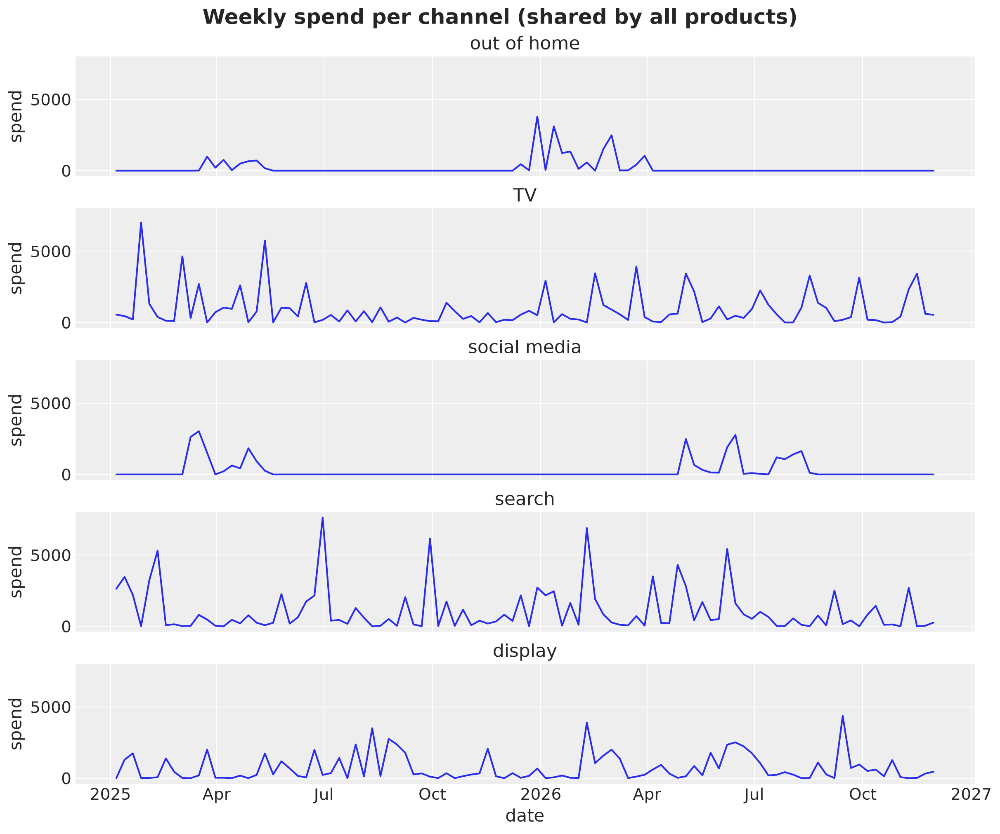

In [4]:
fig, axes = plt.subplots(
    nrows=len(channels),
    ncols=1,
    figsize=(12, 10),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for ax, channel in zip(axes, channels, strict=True):
    ax.plot(channel_values.date, channel_values.sel(channel=channel), color="C0")
    ax.set(title=channel, ylabel="spend")

axes[-1].xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(axes[-1].xaxis.get_major_locator())
)
axes[-1].set(xlabel="date")
fig.suptitle(
    "Weekly spend per channel (shared by all products)", fontsize=18, fontweight="bold"
);

The two campaign channels are zero outside their flights and the three always-on channels never stop. The Gamma draws have heavy right tails, so a channel can jump from a few hundred to above $5{,}000$ in one week. This variation is what lets a model separate the channels later.

**Business Context**: a shared media budget is the common case for a company with several products under one brand. The campaigns are the kind of channel that a planner can switch on and off, the always-on channels are the ones that run every week.

The series are drawn independently, so most correlations should be small. Let's check, because correlated inputs make the channel effects harder to separate.

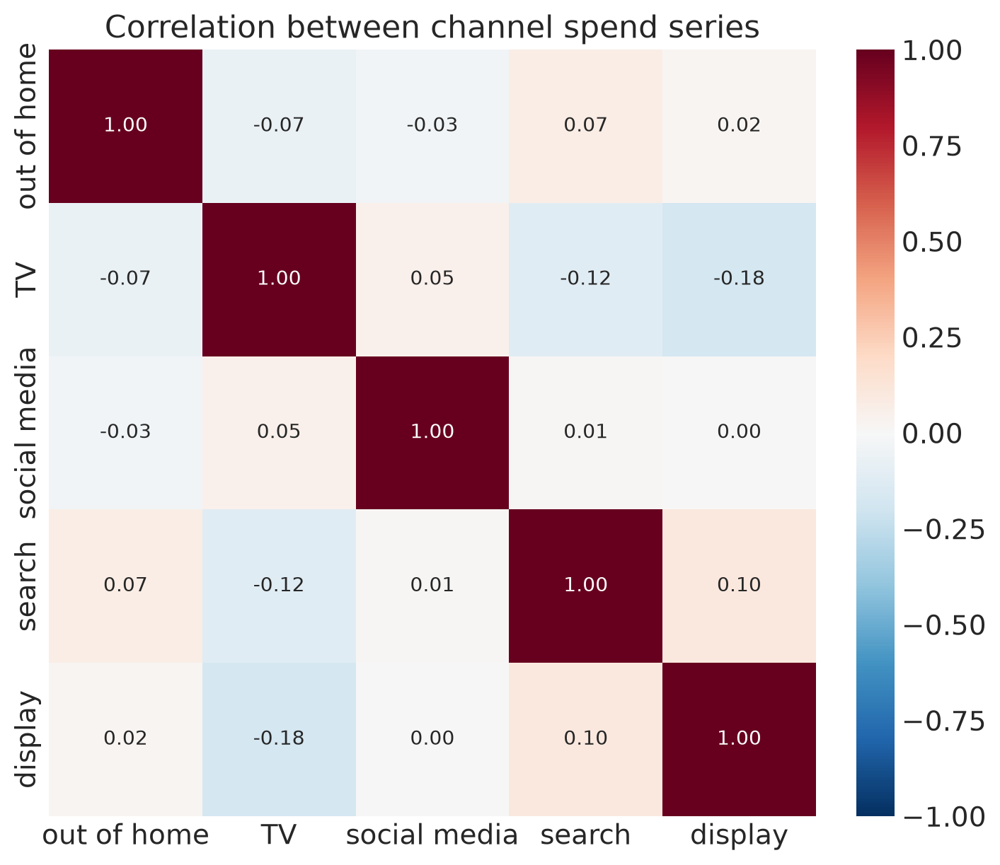

In [5]:
channel_correlations = xr.corr(
    channel_values, channel_values.rename(channel="other_channel"), dim="date"
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    channel_correlations.to_pandas(),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax,
)
ax.set(title="Correlation between channel spend series", xlabel="", ylabel="");

All correlations are small. The largest in absolute value is $-0.18$ between `TV` and `display`. The two campaign channels are at $-0.03$ even though their first flights overlap for nine weeks, because their second flights do not and the draws within the flights are independent. The channel effects are separable from the input side.

### Data Generating Model

Every channel reaches every product, but with its own response curve for each product and each outcome. We write the generator one equation at a time. The index $t$ is the week, $p$ the product, $k$ the outcome, and $c$ the channel.

First, the adstock transformation spreads this week's spend $x_{t,c}$ over the following weeks:

$$
z_{t,p,k,c} = \frac{\sum_{\ell=0}^{6}\rho_{p,k,c}^{\ell}\,x_{t-\ell,c}}{\sum_{\ell=0}^{6}\rho_{p,k,c}^{\ell}}
$$

Here $\rho_{p,k,c}$ is the carry-over rate and $z$ is the spend that still works in week $t$. The weights are normalized, so a constant spend stays constant after the adstock.

Next, the saturation turns the adstocked spend into a contribution with diminishing returns:

$$
f_{t,p,k,c} = A_{p,k,c}\,\frac{z_{t,p,k,c}}{\lambda_{p,k,c} + z_{t,p,k,c}}
$$

$A_{p,k,c}$ is the most a channel can ever add to outcome $k$ of product $p$, and $\lambda_{p,k,c}$ is the adstocked spend at which the channel delivers half of that.

Then comes the spillover. A share of a source product's contribution is *copied* onto another product, the source keeps its full contribution:

$$
S_{t,p,k} = \sum_{s,c} M_{p,s,k,c}\,\kappa_{s,k,c}\,f_{t,s,k,c}
$$

$M$ is a Boolean mask that says which routes exist, and $\kappa$ is the share that travels along a route. In our generator the only routes go from product A to product B for `consideration` and `brand`, through `out of home` and `social media`, with a share of $0.4$. Note that the share is indexed by the source product, the outcome and the channel, not by the receiving product: a source that sent the same channel to two products would pass the same share to both.

The mean of an outcome is the baseline $a_{p,k}$ plus the product's own media plus the incoming spillover:

$$
\mu_{t,p,k} = a_{p,k} + \sum_{c} f_{t,p,k,c} + S_{t,p,k}
$$

Finally, the observed outcome is the mean plus independent noise:

$$
y_{t,p,k} \sim \text{Normal}(\mu_{t,p,k},\ \sigma_{p,k})
$$

The spend $x_{t,c}$ has no product index. `pymc.dims` broadcasts it against parameters with dims `(product, target, channel)` by name, so we never replicate the spend array by hand.

The table maps each symbol to the variable names in the generator and in the `MMM` we fit later:

| Symbol | Meaning | Generator variable | `MMM` variable |
|---|---|---|---|
| $\rho_{p,k,c}$ | adstock carry-over rate | `adstock_alpha` | `adstock_alpha` |
| $A_{p,k,c}$ (later $\alpha_{p,k,c}$) | saturation amplitude, the most a channel can add | `saturation_alpha` | `saturation_alpha` |
| $\lambda_{p,k,c}$ | half-saturation, the adstocked spend that delivers half of $A$ | `saturation_lam` | `saturation_lam` |
| $\kappa_{s,k,c}$ | spillover share along a route | `share` | `spillover_share` |
| $u_{s,k,c}$ | spillover fraction before the cap, $\kappa = 0.5\,u$ | - | `spillover_fraction` |
| $a_{p,k}$ | baseline | `intercept` | `intercept_contribution` |
| $\sigma_{p,k}$ | observation noise | `sigma` | `y_sigma` |

```{note}
**Units**: spend and outcomes are of order thousands. The generator divides spend by `unit_scale = 1,000` before the transformations, so that $A$ and $\lambda$ are of order one, and multiplies the response back. All budgets, figures and tables in this notebook are in the original units.
```

We now build the generator. The spillover mask has dims `(product, source_product, target, channel)` and is `True` only on the routes described above.

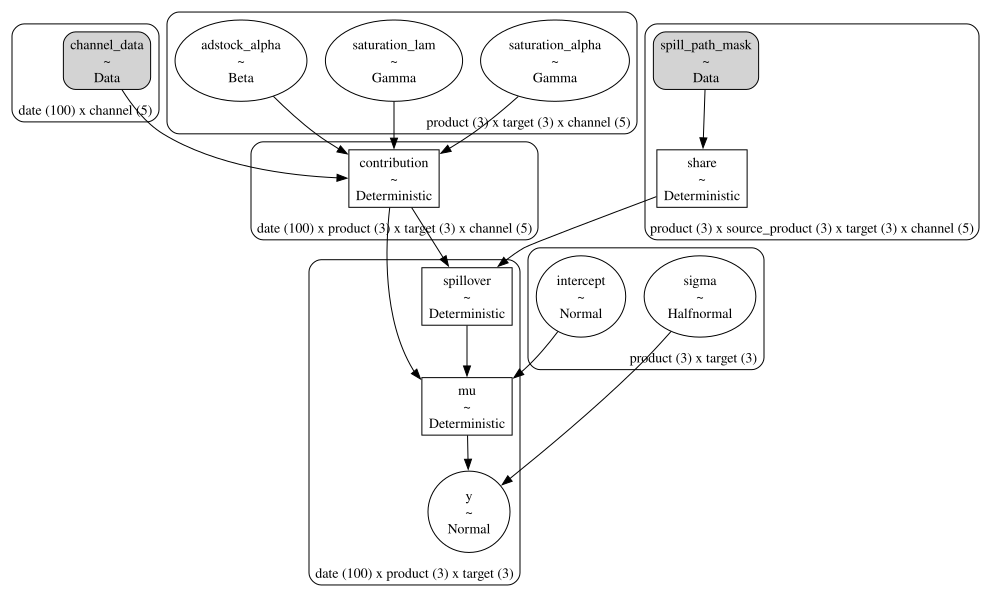

In [6]:
coordinates = {
    "date": dates,
    "channel": channels,
    "product": products,
    "target": targets,
}
parameter_dims = ("product", "target", "channel")
spill_source_dims = ("source_product", "target", "channel")
spill_path_dims = ("product", *spill_source_dims)

# Route mask, (product, source_product, target, channel): product A -> product B for two outcomes and two channels.
spill_mask = xr.DataArray(
    np.zeros((len(products), len(products), len(targets), len(channels)), dtype=bool),
    dims=spill_path_dims,
    coords={
        "product": products,
        "source_product": products,
        "target": targets,
        "channel": channels,
    },
)
spill_mask.loc[
    {
        "product": "product B",
        "source_product": "product A",
        "target": ["consideration", "brand"],
        "channel": ["out of home", "social media"],
    }
] = True
true_spill_share = 0.4

generating_adstock = GeometricAdstock(
    l_max=7,
    normalize=True,
    priors={"alpha": Prior("Beta", alpha=2, beta=2, dims=parameter_dims)},
)
generating_saturation = MichaelisMentenSaturation(
    priors={
        "alpha": Prior("Gamma", mu=2, sigma=1, dims=parameter_dims),
        "lam": Prior("Gamma", mu=1, sigma=0.5, dims=parameter_dims),
    },
)


def build_data_generating_model() -> pm.Model:
    """Build the generator for all products and outcomes, including the spillover route."""
    with pm.Model(coords=coordinates) as model:
        model.add_coord("source_product", values=products)
        # Shared spend, (date, channel), and the fixed route mask.
        channel_data = pmd.Data("channel_data", channel_values)
        path_mask = pmd.Data("spill_path_mask", spill_mask.astype(float))
        # Adstock then saturation, broadcast to (date, product, target, channel).
        adstocked = generating_adstock.apply(channel_data / unit_scale, core_dim="date")
        contribution = pmd.Deterministic(
            "contribution",
            unit_scale * generating_saturation.apply(adstocked),
            dims=("date", "product", "target", "channel"),
        )
        # Spillover: a share of the source product's contribution lands on the receiving product.
        share = pmd.Deterministic("share", true_spill_share * path_mask)
        spillover = pmd.Deterministic(
            "spillover",
            (share * contribution.rename({"product": "source_product"}))
            .sum(dim=("source_product", "channel"))
            .transpose("date", "product", "target"),
        )
        # Baseline, noise scale and the observation model, (date, product, target).
        intercept = Prior(
            "Normal", mu=1, sigma=1, dims=("product", "target")
        ).create_variable("intercept", xdist=True)
        sigma = Prior(
            "HalfNormal", sigma=0.2, dims=("product", "target")
        ).create_variable("sigma", xdist=True)
        mu = pmd.Deterministic(
            "mu",
            unit_scale * intercept + contribution.sum(dim="channel") + spillover,
            dims=("date", "product", "target"),
        )
        pmd.Normal(
            "y", mu=mu, sigma=unit_scale * sigma, dims=("date", "product", "target")
        )

    return model


data_generating_model = build_data_generating_model()
pm.model_to_graphviz(data_generating_model)

The spend enters once as `channel_data` with dims `(date, channel)`. The three media parameter blocks carry the `product`, `target` and `channel` plates, `share` and `spill_path_mask` form the route, and `mu` collects the baseline, the own media and the spillover before the Normal likelihood.

### Simulated Outcomes

We fix the parameters with `pm.do` and draw the outcomes. The `sales` amplitudes encode the conflict we want to study: product A's sales respond to `out of home` and `TV`, product B's sales respond to `search` and `display`, and product C sits in between. For `consideration`, all three products lean towards `search` and `display`, and product A also responds to `out of home` and `social media`, which is what feeds the spillover route.

For `sales` we use the same carry-over and half-saturation for every product, so the sales trade-off comes only from the amplitudes and is easy to read. The other parameters are drawn at random within sensible ranges. `brand` is a copy of `consideration` with twice the observation noise: think of a survey metric that tracks the same demand, only more noisily. We keep it to see what noise alone does to an optimized allocation.

In [7]:
true_parameters = {
    # Saturation amplitudes A, (product, target, channel) after the stack: sales first, consideration second.
    "saturation_alpha": np.stack(
        [
            # sales: product A -> out of home and TV, product B -> search and display, product C in between
            np.array(
                [
                    [4.0, 3.0, 0.8, 0.05, 0.05],
                    [0.05, 0.05, 0.8, 3.0, 4.0],
                    [1.8, 1.0, 1.2, 0.4, 0.2],
                ]
            ),
            # consideration: all lean to search and display, product A also uses the two campaign channels
            np.array(
                [
                    [1.0, 0.3, 1.0, 1.5, 2.0],
                    [0.4, 0.2, 0.6, 2.2, 1.2],
                    [0.1, 0.5, 1.0, 1.4, 1.8],
                ]
            ),
        ],
        axis=1,
    ),
    "adstock_alpha": rng.uniform(0.2, 0.7, size=(len(products), 2, len(channels))),
    "saturation_lam": rng.uniform(0.5, 1.5, size=(len(products), 2, len(channels))),
    "intercept": np.array([[1.0, 2.0], [1.5, 1.0], [2.0, 1.5]]),
    "sigma": np.array([[0.15, 0.25], [0.20, 0.15], [0.25, 0.20]]),
}
# Sales share the carry-over and half-saturation across products.
true_parameters["adstock_alpha"][:, 0, :] = [0.25, 0.4, 0.35, 0.4, 0.25]
true_parameters["saturation_lam"][:, 0, :] = 0.8

# Brand copies consideration (index 1), with twice the observation noise.
for name, values in true_parameters.items():
    brand_values = values[:, 1:2] * (2.0 if name == "sigma" else 1.0)
    true_parameters[name] = np.concatenate([values, brand_values], axis=1)

generative_model = pm.do(data_generating_model, true_parameters)
true_mu_values, true_contribution_values, true_spillover_values, observed_values = (
    pm.draw(
        [
            generative_model["mu"],
            generative_model["contribution"],
            generative_model["spillover"],
            generative_model["y"],
        ],
        random_seed=seed,
    )
)

outcome_coords = {dim: coordinates[dim] for dim in ("date", "product", "target")}
true_mu = xr.DataArray(
    true_mu_values, dims=("date", "product", "target"), coords=outcome_coords
)
true_contribution = xr.DataArray(
    true_contribution_values,
    dims=("date", "product", "target", "channel"),
    coords=coordinates,
)
true_spillover = xr.DataArray(
    true_spillover_values, dims=("date", "product", "target"), coords=outcome_coords
)
target_values = xr.DataArray(
    observed_values, dims=("date", "product", "target"), coords=outcome_coords, name="y"
)

Let's look at the nine simulated outcome series.

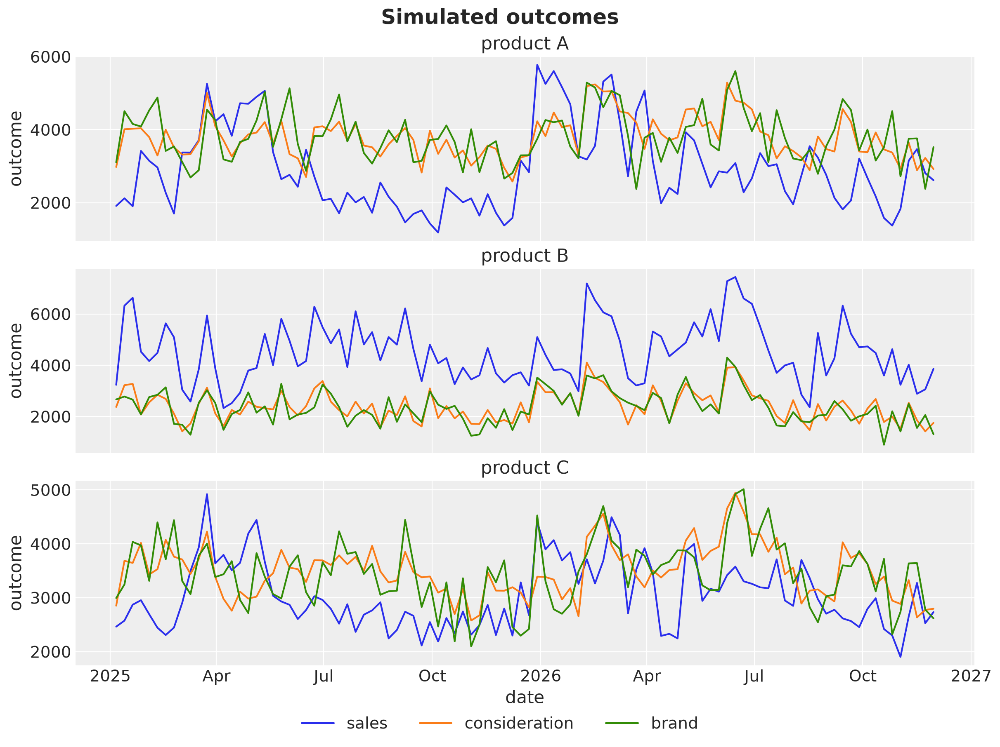

In [8]:
fig, axes = plt.subplots(
    nrows=len(products), ncols=1, figsize=(12, 9), sharex=True, layout="constrained"
)

for ax, product in zip(axes, products, strict=True):
    for j, target in enumerate(targets):
        ax.plot(
            dates,
            target_values.sel(product=product, target=target),
            color=f"C{j}",
            label=target,
        )

    ax.set(title=product, ylabel="outcome")

axes[-1].xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(axes[-1].xaxis.get_major_locator())
)
axes[-1].set(xlabel="date")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
fig.suptitle("Simulated outcomes", fontsize=18, fontweight="bold");

Product A's sales jump with the `out of home` flights, product B's sales follow `search` and `display`, and product C sits between the two. In every panel `consideration` and `brand` move together, with `brand` the noisier of the two.

The brand series should follow consideration closely, with more scatter. Let's check with a scatter plot per product.

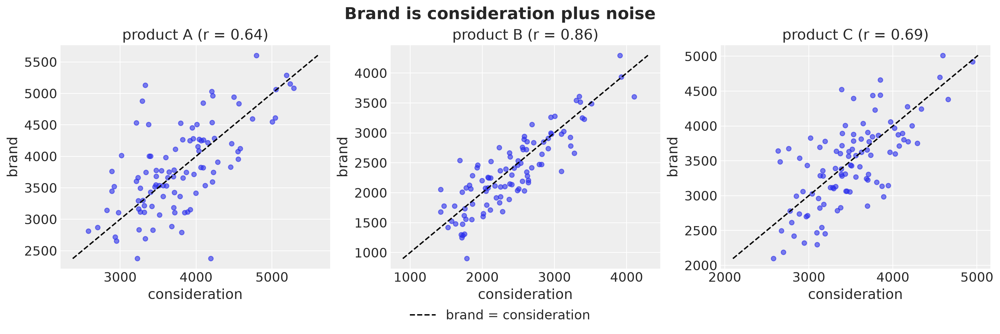

In [9]:
fig, axes = plt.subplots(
    nrows=1, ncols=len(products), figsize=(15, 5), layout="constrained"
)

for ax, product in zip(axes, products, strict=True):
    consideration_observed = target_values.sel(product=product, target="consideration")
    brand_observed = target_values.sel(product=product, target="brand")
    correlation = np.corrcoef(consideration_observed, brand_observed)[0, 1]
    limits = np.array(
        [
            min(consideration_observed.min(), brand_observed.min()),
            max(consideration_observed.max(), brand_observed.max()),
        ]
    )
    ax.scatter(consideration_observed, brand_observed, color="C0", alpha=0.6, s=25)
    ax.plot(
        limits, limits, color="black", linestyle="--", label="brand = consideration"
    )
    ax.set(
        title=f"{product} (r = {correlation:.2f})",
        xlabel="consideration",
        ylabel="brand",
    )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=1)
fig.suptitle("Brand is consideration plus noise", fontsize=18, fontweight="bold");

The correlation between the two observed series is $0.64$, $0.86$ and $0.69$ for the three products, and the points scatter around the identity line without a tilt, as designed: same mean, more noise.

## The Pareto Frontier

Before fitting anything, let's look at the conflict in the true model. The spillover route does not touch `sales`, so for `sales` the steady-state response of a product is just the sum of its own saturation curves. That makes `sales` the clean case to trace the frontier with the true parameters. We come back to `consideration` with the fitted model, where the spillover is part of the response.

### Channel Sweep

We fix a weekly budget of $5{,}000$ and move it between the two channel groups: at one end all of it goes to `search` and `display` (product B's channels), at the other end to `out of home` and `TV` (product A's channels). `social media` keeps a fifth of the budget throughout.

With normalized adstock, a constant weekly allocation reaches its steady state after $7$ weeks, and the steady-state response is the saturation curve evaluated at that allocation. So we can compute the media-driven sales of each product directly from the parameters, without simulating weeks.

In [10]:
weekly_budget = 5.0 * unit_scale
allocation_fraction = np.linspace(0.0, 1.0, 101)

# Sweep allocations, (allocation, channel): fraction 0 favors product B, fraction 1 favors product A.
allocation_sweep = xr.DataArray(
    np.column_stack(
        [
            0.4 * weekly_budget * allocation_fraction,
            0.4 * weekly_budget * allocation_fraction,
            np.full_like(allocation_fraction, 0.2 * weekly_budget),
            0.4 * weekly_budget * (1.0 - allocation_fraction),
            0.4 * weekly_budget * (1.0 - allocation_fraction),
        ]
    ),
    dims=("allocation", "channel"),
    coords={"allocation": allocation_fraction, "channel": channels},
)

# True saturation parameters in original units, (product, target, channel).
true_maximum = xr.DataArray(
    unit_scale * true_parameters["saturation_alpha"],
    dims=parameter_dims,
    coords={dim: coordinates[dim] for dim in parameter_dims},
)
true_half_saturation = xr.DataArray(
    unit_scale * true_parameters["saturation_lam"],
    dims=parameter_dims,
    coords={dim: coordinates[dim] for dim in parameter_dims},
)
sweep_response = (
    true_maximum * allocation_sweep / (true_half_saturation + allocation_sweep)
).sum("channel")
sweep_sales_a = sweep_response.sel(product="product A", target="sales")
sweep_sales_b = sweep_response.sel(product="product B", target="sales")

Let's plot product B's sales against product A's sales along the sweep.

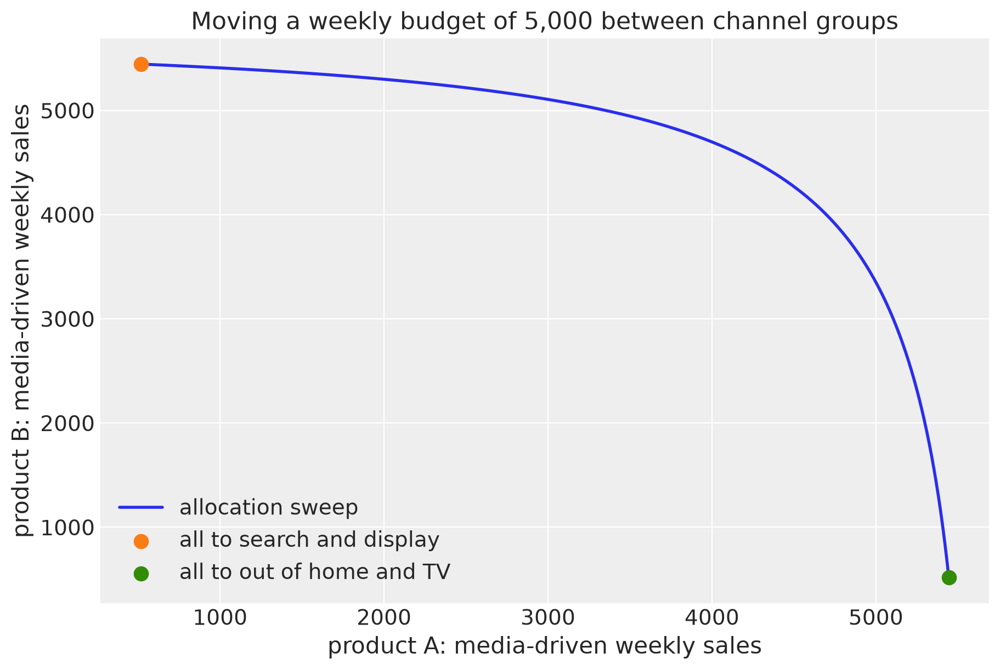

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(sweep_sales_a, sweep_sales_b, color="C0", linewidth=2, label="allocation sweep")

for fraction, label, color in [
    (0.0, "all to search and display", "C1"),
    (1.0, "all to out of home and TV", "C2"),
]:
    ax.scatter(
        sweep_sales_a.sel(allocation=fraction),
        sweep_sales_b.sel(allocation=fraction),
        s=80,
        color=color,
        zorder=3,
        label=label,
    )

ax.set(
    xlabel="product A: media-driven weekly sales",
    ylabel="product B: media-driven weekly sales",
    title=f"Moving a weekly budget of {weekly_budget:,.0f} between channel groups",
)
ax.legend(loc="lower left");

The curve is bent. Both ends are corner plans: all money to one product's channels gives that product about $5{,}450$ and the other about $500$. Because of saturation, the first units moved away from a product's best channels cost it little and the last units cost it a lot. This is what makes a balanced plan attractive rather than a corner.

### Frontier Surface

The sweep only moves budget along one line. Now we optimize all five channel budgets, still summing to $5{,}000$ per week, for all three products at once. Let's fix the notation. The decision is the weekly budget by channel, $b = (b_1, \dots, b_5)$. For product $p$, $R_p(b)$ is the weekly sales that media bring in once the plan has run long enough to settle, so it is the quantity on the axes of the sweep above, now for any budget vector. This section is about `sales` only, so we drop the outcome index $k$. $R_p(b)$ is the sum of the product's five saturation curves, each evaluated at its channel's budget:

$$
R_p(b) = \sum_{c} A_{p,c}\,\frac{b_c}{\lambda_{p,c} + b_c}
$$

And $I_p = \max_b R_p(b)$, with the maximum taken over the budgets that sum to the weekly total, is the best product $p$ could get if the whole budget served it alone, its *ideal*. The ideal depends on the total budget: with $5{,}000$ per week it is one number, with $10{,}000$ another.

To trace the frontier we maximize weighted sums $\sum_p w_p\,R_p(b) / I_p$ over a grid of weights $w$. Each $R_p$ is a sum of concave curves, so every efficient plan is the maximizer of some weighted sum and the grid does not miss any part of the frontier. Dividing by $I_p$ makes the weights priorities: equal weights mean "each product matters equally relative to its own potential", not "one unit of product C's sales is worth one unit of product A's". This is the weighted-sum scalarization of [multi-objective optimization](https://en.wikipedia.org/wiki/Multi-objective_optimization), and the frontier it traces is the set of [Pareto efficient](https://en.wikipedia.org/wiki/Pareto_efficiency) plans.

To pick one plan on the frontier we use a **max-min rule**. We maximize the smallest fraction of its own ideal that any product reaches:

$$
\max_{b,\,t}\ t
\qquad\text{s.t.}\qquad
\frac{R_p(b)}{I_p} \geq t \ \text{ for every product } p,
\qquad b_c \geq 0,
\qquad \sum_c b_c = 5{,}000.
$$

Here is the intuition. A plan that gives product A $90\%$ of its ideal, product B $90\%$ and product C $60\%$ has a score of $0.60$, the worst-off product. The max-min plan is the one with the highest such score, so it protects the product that is worst off relative to its own potential. It does not equalize raw sales, which would make little sense for products of different sizes.

We need three helpers for this. The first evaluates $R_p(b)$ and its gradient with respect to each channel budget, and it accepts either one parameter set or a stack of posterior draws, because we will reuse it on the fitted model. The second solves the weighted-sum problem for one weight vector. The third solves the max-min problem.

Let's start with the response and its gradient. With a stack of draws the function returns the posterior mean of both, which is what the optimizers below need.

In [12]:
def product_response_and_gradient(
    allocation: np.ndarray, maximum: np.ndarray, half_saturation: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Compute the steady-state response per product and its gradient per channel budget.

    ``maximum`` and ``half_saturation`` have shape ``(product, channel)`` or ``(sample, product, channel)``.
    With samples, the response and the gradient are averaged over the draws.
    """
    # Saturation curve per (product, channel) and its derivative with respect to the budget.
    denominator = half_saturation + allocation
    response = (maximum * allocation / denominator).sum(axis=-1)
    gradient = maximum * half_saturation / denominator**2

    # Average over any leading sample axes.
    sample_axes = tuple(range(maximum.ndim - 2))
    if sample_axes:
        response = response.mean(axis=sample_axes)
        gradient = gradient.mean(axis=sample_axes)

    return response, gradient

Next, the weighted-sum problem. We optimize budget fractions that sum to one with SLSQP and scale the objective by `unit_scale` so that the solver tolerance has a sensible meaning.

In [13]:
def weighted_product_allocation(
    weights: np.ndarray,
    maximum: np.ndarray,
    half_saturation: np.ndarray,
    total_budget: float,
) -> np.ndarray:
    """Maximize a weighted sum of product responses at a fixed total budget."""
    n_channels = maximum.shape[-1]
    weights = weights / weights.sum()

    def objective(fractions: np.ndarray) -> tuple[float, np.ndarray]:
        response, gradient = product_response_and_gradient(
            fractions * total_budget, maximum, half_saturation
        )
        return (
            -float(weights @ response) / unit_scale,
            -(weights @ gradient) * total_budget / unit_scale,
        )

    result = minimize(
        objective,
        x0=np.full(n_channels, 1.0 / n_channels),
        jac=True,
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n_channels,
        constraints=[
            {
                "type": "eq",
                "fun": lambda fractions: fractions.sum() - 1.0,
                "jac": lambda fractions: np.ones(n_channels),
            }
        ],
        options={"ftol": 1e-11, "maxiter": 500},
    )
    if not result.success:
        raise RuntimeError(f"Weighted-sum optimization failed: {result.message}")

    return result.x * total_budget

Finally, the max-min problem. The trick is one extra decision variable $t$, the attainment level, which turns the non-smooth "minimum over products" into smooth inequality constraints.

In [14]:
def balanced_product_allocation(
    maximum: np.ndarray,
    half_saturation: np.ndarray,
    ideal_response: np.ndarray,
    starting_budget: np.ndarray,
    total_budget: float,
) -> tuple[np.ndarray, float]:
    """Maximize the smallest fraction of each product's ideal response (max-min)."""
    n_products, n_channels = maximum.shape[-2:]

    def balance_constraints(decision: np.ndarray) -> np.ndarray:
        response, _ = product_response_and_gradient(
            decision[:-1] * total_budget, maximum, half_saturation
        )
        return response / ideal_response - decision[-1]

    def balance_constraint_gradient(decision: np.ndarray) -> np.ndarray:
        _, gradient = product_response_and_gradient(
            decision[:-1] * total_budget, maximum, half_saturation
        )
        return np.column_stack(
            [gradient * total_budget / ideal_response[:, None], -np.ones(n_products)]
        )

    starting_response, _ = product_response_and_gradient(
        starting_budget, maximum, half_saturation
    )
    # Decision vector: five budget fractions followed by the attainment level t.
    result = minimize(
        lambda decision: -decision[-1],
        x0=np.r_[
            starting_budget / total_budget, (starting_response / ideal_response).min()
        ],
        jac=lambda decision: np.r_[np.zeros(n_channels), -1.0],
        method="SLSQP",
        bounds=[(0.0, 1.0)] * (n_channels + 1),
        constraints=[
            {
                "type": "eq",
                "fun": lambda decision: decision[:-1].sum() - 1.0,
                "jac": lambda decision: np.r_[np.ones(n_channels), 0.0],
            },
            {
                "type": "ineq",
                "fun": balance_constraints,
                "jac": balance_constraint_gradient,
            },
        ],
        options={"ftol": 1e-11, "maxiter": 500},
    )
    if not result.success:
        raise RuntimeError(f"Max-min optimization failed: {result.message}")

    return result.x[:-1] * total_budget, -float(result.fun)

Now we trace the `sales` frontier. The weight grid has $91$ points on the simplex, shifted slightly away from the edges so that no product gets exactly zero weight.

In [15]:
frontier_resolution = 12
preference_weights = (
    np.array(
        [
            (i, j, frontier_resolution - i - j)
            for i in range(frontier_resolution + 1)
            for j in range(frontier_resolution + 1 - i)
        ],
        dtype=float,
    )
    / frontier_resolution
)
preference_weights = (preference_weights + 0.01) / 1.03
frontier_triangles = Triangulation(
    preference_weights[:, 0], preference_weights[:, 1]
).triangles

# True sales parameters, (product, channel).
sales_true_maximum = (
    true_maximum.sel(target="sales").transpose("product", "channel").values
)
sales_true_half_saturation = (
    true_half_saturation.sel(target="sales").transpose("product", "channel").values
)

# Ideal response per product: the whole budget serves one product.
individual_allocations = np.stack(
    [
        weighted_product_allocation(
            weights, sales_true_maximum, sales_true_half_saturation, weekly_budget
        )
        for weights in np.eye(len(products))
    ]
)
true_ideal_sales = np.array(
    [
        product_response_and_gradient(
            allocation, sales_true_maximum, sales_true_half_saturation
        )[0][p]
        for p, allocation in enumerate(individual_allocations)
    ]
)

# Frontier: one weighted-sum optimum per weight vector, (weight, channel) and (weight, product).
frontier_budgets = np.stack(
    [
        weighted_product_allocation(
            weights / true_ideal_sales,
            sales_true_maximum,
            sales_true_half_saturation,
            weekly_budget,
        )
        for weights in preference_weights
    ]
)
frontier_response = np.stack(
    [
        product_response_and_gradient(
            allocation, sales_true_maximum, sales_true_half_saturation
        )[0]
        for allocation in frontier_budgets
    ]
)

# Max-min plan, starting from the average of the three single-product optima.
true_balanced_budget, true_balance_score = balanced_product_allocation(
    sales_true_maximum,
    sales_true_half_saturation,
    true_ideal_sales,
    individual_allocations.mean(axis=0),
    weekly_budget,
)
true_balanced_response, _ = product_response_and_gradient(
    true_balanced_budget, sales_true_maximum, sales_true_half_saturation
)
near_balance = (frontier_response / true_ideal_sales).min(
    axis=1
) >= 0.98 * true_balance_score

Let's look at the frontier. Each point on the surface is one allocation, and the axes are the three products' media-driven sales. The diamond is the max-min plan, and the highlighted points are the sampled plans that come within $2\%$ of its score. The figure is interactive: drag to rotate, hover for the three values.

In [16]:
hover_template = (
    "product A %{x:,.0f}<br>product B %{y:,.0f}<br>product C %{z:,.0f}<extra></extra>"
)
frontier_figure = go.Figure(
    data=[
        go.Mesh3d(
            x=frontier_response[:, 0],
            y=frontier_response[:, 1],
            z=frontier_response[:, 2],
            i=frontier_triangles[:, 0],
            j=frontier_triangles[:, 1],
            k=frontier_triangles[:, 2],
            opacity=0.35,
            color="#1f77b4",
            name="frontier surface",
            showlegend=True,
            hoverinfo="skip",
        ),
        go.Scatter3d(
            x=frontier_response[:, 0],
            y=frontier_response[:, 1],
            z=frontier_response[:, 2],
            mode="markers",
            marker={"size": 3, "color": "#1f77b4"},
            name="sampled plans",
            hovertemplate=hover_template,
        ),
        go.Scatter3d(
            x=frontier_response[near_balance, 0],
            y=frontier_response[near_balance, 1],
            z=frontier_response[near_balance, 2],
            mode="markers",
            marker={"size": 5, "color": "#ff7f0e"},
            name="within 2% of the max-min score",
            hovertemplate=hover_template,
        ),
        go.Scatter3d(
            x=[true_balanced_response[0]],
            y=[true_balanced_response[1]],
            z=[true_balanced_response[2]],
            mode="markers",
            marker={"size": 9, "symbol": "diamond", "color": "#d62728"},
            name="max-min plan",
            hovertemplate=hover_template,
        ),
    ]
)
frontier_figure.update_layout(
    title=f"Sales frontier at {weekly_budget:,.0f} per week (max-min score {true_balance_score:.1%})",
    scene={
        "xaxis_title": "product A sales",
        "yaxis_title": "product B sales",
        "zaxis_title": "product C sales",
    },
    legend={"orientation": "h", "y": -0.02},
    width=850,
    height=650,
    margin={"l": 0, "r": 0, "b": 0, "t": 50},
)
frontier_figure.show()

The surface is curved, with the single-product plans at its corners and the max-min plan close to its middle, where products A and B reach the same share of their ideals. The max-min score is $81.5\%$: no product gets less than $81.5\%$ of what it would get with the whole budget to itself. The orange points are the sampled plans whose worst-off product is within $2\%$ of that score.

How sharp is the choice? The grid points are coarse, so we check it directly: we take the max-min plan, move $2\%$, $5\%$ or $10\%$ of the budget between channels in random directions, drop the moves that would push a channel below zero, and score every perturbed plan by its worst-off product. A separate random generator keeps this check from changing the draws of the rest of the notebook.

In [17]:
perturbation_rng = np.random.default_rng(seed=seed)
perturbation_fractions = [0.02, 0.05, 0.10]
n_perturbations = 2_000

perturbation_rows = []

for fraction in perturbation_fractions:
    # Zero-sum random directions, scaled so that the amount moved between channels is `fraction` of the budget.
    directions = perturbation_rng.dirichlet(
        np.ones(len(channels)), size=n_perturbations
    ) - perturbation_rng.dirichlet(np.ones(len(channels)), size=n_perturbations)
    directions /= np.abs(directions).sum(axis=1, keepdims=True) / 2.0
    perturbed_budgets = true_balanced_budget + fraction * weekly_budget * directions
    perturbed_budgets = perturbed_budgets[(perturbed_budgets >= 0.0).all(axis=1)]
    # Response per perturbed plan and product, (plan, product), and the worst-off share of the ideal.
    perturbed_response, _ = product_response_and_gradient(
        perturbed_budgets[:, None, :], sales_true_maximum, sales_true_half_saturation
    )
    score_loss = 100 * (
        true_balance_score - (perturbed_response / true_ideal_sales).min(axis=1)
    )
    perturbation_rows.append(
        {
            "budget moved (%)": 100 * fraction,
            "plans": len(perturbed_budgets),
            "median loss (points)": np.median(score_loss),
            "95th percentile loss (points)": np.percentile(score_loss, 95),
        }
    )

pd.DataFrame(perturbation_rows).set_index("budget moved (%)").round(2)

,plans,median loss (points),95th percentile loss (points)
budget moved (%),,,
2.0,2000,0.68,1.30
5.0,2000,1.92,3.48
10.0,1976,4.53,7.76


Moving $2\%$ of the budget costs less than one point of the score at the median and about $1.3$ points in the worst $5\%$ of directions. Moving $5\%$ costs about $2$ points at the median, and $10\%$ about $4.5$ points. The score falls gently around the max-min plan, so the choice is not knife-edge: a planner who has to round the plan to budget lines loses little.

### Max-Min Balance

Let's see what the max-min plan spends per channel.

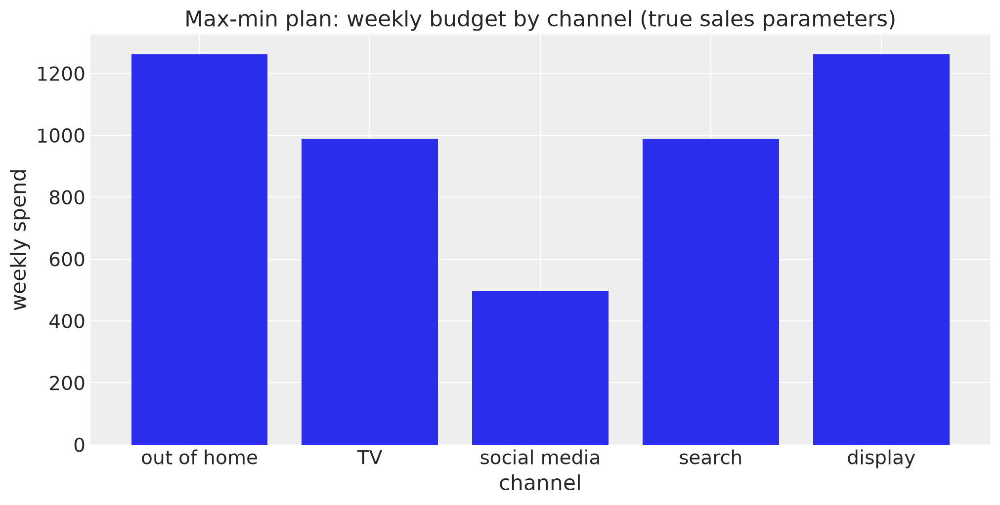

In [18]:
true_balanced_allocation = pd.Series(
    true_balanced_budget, index=pd.Index(channels, name="channel")
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(true_balanced_allocation.index, true_balanced_allocation.values, color="C0")
ax.set(
    title="Max-min plan: weekly budget by channel (true sales parameters)",
    xlabel="channel",
    ylabel="weekly spend",
);

The plan is symmetric between the two products' channel pairs: about $1{,}260$ per week on `out of home` and on `display`, about $990$ on `TV` and on `search`, and the remaining $500$ on `social media`, the one channel all three products share.

And what each product gets, next to its ideal.

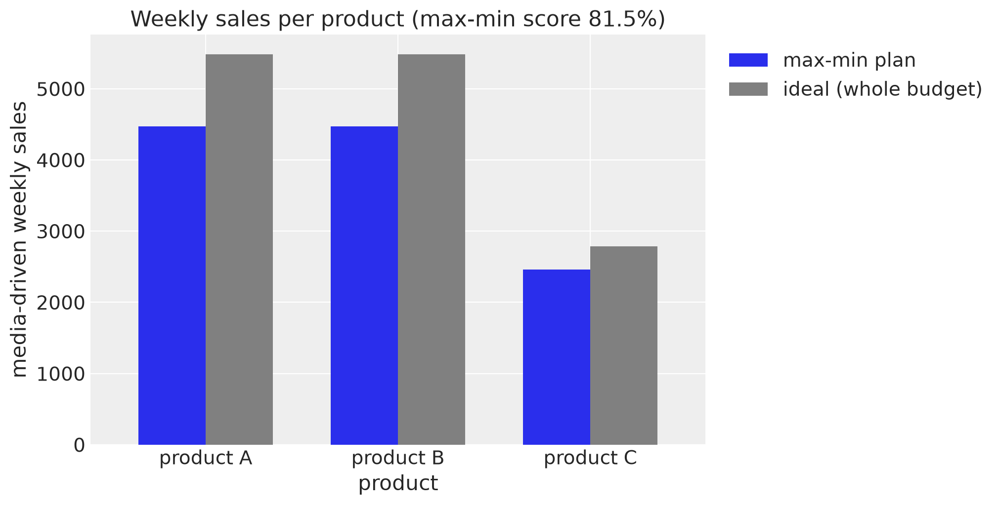

In [19]:
true_sales_comparison = pd.DataFrame(
    {"max-min plan": true_balanced_response, "ideal (whole budget)": true_ideal_sales},
    index=pd.Index(products, name="product"),
)

fig, ax = plt.subplots(figsize=(10, 5))
true_sales_comparison.plot.bar(ax=ax, rot=0, width=0.7, color=["C0", "gray"])

ax.set(
    title=f"Weekly sales per product (max-min score {true_balance_score:.1%})",
    xlabel="product",
    ylabel="media-driven weekly sales",
)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0));

Products A and B both get about $4{,}470$ in weekly sales, $81.5\%$ of their ideal of about $5{,}500$. Product C gets about $2{,}460$, which is about $88\%$ of its ideal of about $2{,}800$: its constraint does not bind, so the max-min rule is really balancing product A against product B, and product C comes along because its channels are a blend of the other two. Product C gets less in absolute terms because its response curves are smaller, but the max-min rule compares each product with its own best, not with the others.

**Business Value**: the frontier turns "how much should each product get" from a negotiation into a picture. Every efficient plan is on the surface, the corners are the single-product plans, and the max-min rule is one defensible way to pick a point that no product can call unfair relative to its own potential.

## Model Specification

Now we forget the true parameters and specify the model we would fit on real data. We use the library's {class}`~pymc_marketing.mmm.MMM` class with two extra dimensions, `product` and `target`, so one model carries all nine outcome series. The class wants a long table with one row per date, product and outcome, and one column per channel. Our spend is shared, so the same five numbers are repeated for every product and outcome of a week.

The `MMM` scales its inputs before fitting. We scale every channel's spend by that channel's mean weekly spend *over the weeks it is on*, $\tilde{x}_{t,c} = x_{t,c} / s_c$, so that a typical active week has a scaled spend around $1$. The distinction matters for the two campaign channels: they are off in three quarters of the weeks, so their mean over all weeks is about a quarter of a flight week. With that scale, $\lambda = 1$ would mean "half saturated at a quarter of a typical flight week", and a prior centered there would put the plausible half-saturation points of a flight week in its far tail. The same reasoning applies to real data: scale a channel by what a typical week *with* spend looks like. Every outcome is divided by the largest observed outcome, $\tilde{y}_{t,p,k} = y_{t,p,k} / s_y$. The model equations are the ones of the generator, written on the scaled data. First, the adstock:

$$
\tilde{z}_{t,p,k,c} = \frac{\sum_{\ell=0}^{6}\rho_{p,k,c}^{\ell}\,\tilde{x}_{t-\ell,c}}{\sum_{\ell=0}^{6}\rho_{p,k,c}^{\ell}}
$$

Next, the saturation with amplitude $\alpha$ and half-saturation $\lambda$, both now in scaled units:

$$
\tilde{f}_{t,p,k,c} = \alpha_{p,k,c}\,\frac{\tilde{z}_{t,p,k,c}}{\lambda_{p,k,c} + \tilde{z}_{t,p,k,c}}
$$

Then the spillover, with the same routes as the generator but a learned share $\kappa_{s,k,c}$:

$$
\tilde{S}_{t,p,k} = \sum_{s,c} M_{p,s,k,c}\,\kappa_{s,k,c}\,\tilde{f}_{t,s,k,c}
$$

And the mean and the likelihood:

$$
\tilde{\mu}_{t,p,k} = a_{p,k} + \sum_c \tilde{f}_{t,p,k,c} + \tilde{S}_{t,p,k},
\qquad
\tilde{y}_{t,p,k} \sim \text{Normal}(\tilde{\mu}_{t,p,k},\ \sigma_{p,k})
$$

The model has the same shape as the generator but a different parametrization, so we will check recovery on contributions in original units, not on raw parameters.

### Priors

Every parameter gets one prior, with dims `(product, target, channel)` for the media parameters and `(product, target)` for the baseline and the noise:

$$
\rho_{p,k,c} \sim \text{Beta}(2, 2)
$$

$$
\alpha_{p,k,c} \sim \text{Gamma}(\mu=0.25, \sigma=0.25)
$$

$$
\lambda_{p,k,c} \sim \text{Gamma}(\mu=1, \sigma=0.5)
$$

$$
a_{p,k} \sim \text{Normal}(0.3, 0.3)
$$

$$
\sigma_{p,k} \sim \text{HalfNormal}(0.05)
$$

$$
u_{s,k,c} \sim \text{Beta}(2, 2), \qquad \kappa_{s,k,c} = 0.5\,u_{s,k,c}
$$

Here is what these mean on the scale of the data. The carry-over $\rho$ is centered at $0.5$, a half-life of about a week, and allows anything between no carry-over and a long tail. The amplitude $\alpha$ is in units of the largest observed outcome, so $\alpha=1$ means a channel could at most add one maximum outcome per week. With five channels per outcome, a quarter of the maximum each is a generous ceiling, so the prior centers $\alpha$ at $0.25$ and rarely goes above one. The half-saturation $\lambda$ is in units of each channel's mean active-week spend, so $\lambda=1$ means the channel is half saturated in a typical week with spend. We keep $\lambda$ away from zero on purpose: a channel with $\lambda \approx 0$ delivers its full amplitude at any positive spend, which turns an always-on channel into a constant that the model cannot tell apart from the baseline. The baseline $a$ is a fraction of the largest outcome, and since the lowest observed outcomes are between a tenth and a third of the largest, the prior centers it at $0.3$ with a spread of $0.3$. The noise $\sigma$ is about $5\%$ of the largest outcome, since the week-to-week scatter of the series is a few hundred.

The spillover share $\kappa$ is the product of a cap and a fraction, and both are choices. The cap of $0.5$ says that a route can pass at most half of the source's own lift to the receiving product: a share near one would mean that product B responds to product A's campaigns as strongly as product A itself, which is not a spillover any more. The fraction prior $\text{Beta}(2, 2)$ puts the share between $0$ and $50\%$ with a mean of $25\%$ and little mass near zero, only about $3\%$ of it below a share of $5\%$. That is intended: the mask already states that the route exists, so the prior says "there is a route, we do not know how large". If the existence of a route were itself in question, the prior should have mass at zero, for example $\text{Beta}(1, 3)$, or the model should be compared with and without the route.

Let's plot the priors with `preliz`.

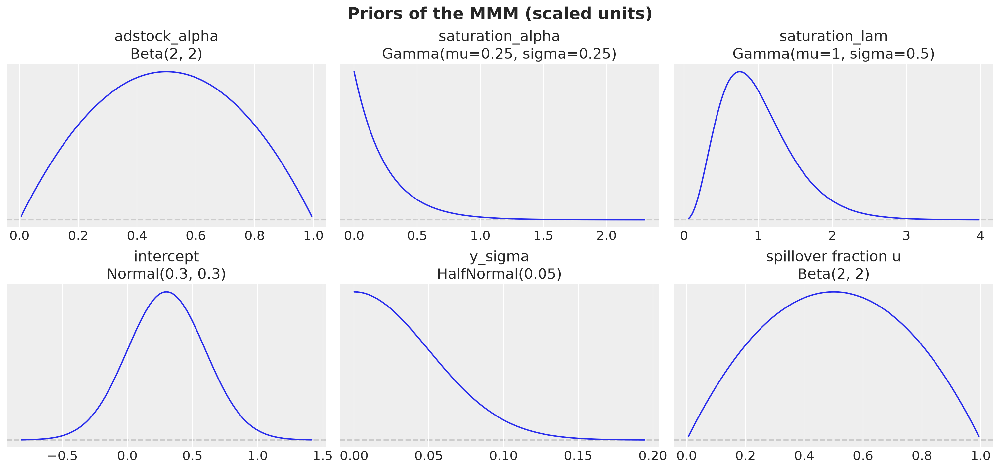

In [20]:
prior_specs = {
    "adstock_alpha\nBeta(2, 2)": Prior("Beta", alpha=2, beta=2),
    "saturation_alpha\nGamma(mu=0.25, sigma=0.25)": Prior("Gamma", mu=0.25, sigma=0.25),
    "saturation_lam\nGamma(mu=1, sigma=0.5)": Prior("Gamma", mu=1, sigma=0.5),
    "intercept\nNormal(0.3, 0.3)": Prior("Normal", mu=0.3, sigma=0.3),
    "y_sigma\nHalfNormal(0.05)": Prior("HalfNormal", sigma=0.05),
    "spillover fraction u\nBeta(2, 2)": Prior("Beta", alpha=2, beta=2),
}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 7), layout="constrained")

for ax, (title, prior) in zip(axes.ravel(), prior_specs.items(), strict=True):
    prior.preliz.plot_pdf(ax=ax, color="C0", legend=None)
    ax.set_title(title)

fig.suptitle("Priors of the MMM (scaled units)", fontsize=18, fontweight="bold");

All six priors are wide on the scaled data but keep the response in a plausible range: the amplitude prior puts a channel's ceiling below the largest outcome and is free to reach zero, as a channel with no effect needs, the half-saturation prior puts little mass near zero, which is the one place we want to avoid, and the spillover fraction is a symmetric bump around a half.

### Spillover Effect

The `MMM` class accepts additive terms through the {class}`~pymc_marketing.mmm.additive_effect.MuEffect` interface. An effect implements three methods: `create_data` registers the data it needs, `create_effect` returns a term with dims `(date, product, target)` that is added to the mean, and `set_data` updates the data for predictions. Our effect reads the model's own `channel_contribution`, which is already adstocked and saturated, renames its `product` dimension to `source_product`, multiplies by the learned share on the active routes and sums over sources and channels. {class}`~pymc_marketing.special_priors.MaskedPrior` samples only the four active shares and fills the other positions with exact zeros. The share has dims `(source_product, target, channel)`, which is the assumption stated with the generator: the receiving product comes from the mask, and a source sending the same channel to two products would use one share for both. The class carries its dimension names as class attributes, so it can be copied into another project as is.

```{note}
**Two practical details**: the `MMM` stores its effects in `idata.attrs` when it fits, so the class has to say how to turn itself into a dictionary and back (`to_dict`, `from_dict`). And the `MMM` sorts coordinate labels alphabetically, so the effect aligns the route mask to the model's coordinates before flattening it. Without that step the shares would land on the wrong routes.
```

In [21]:
class SpilloverEffect(MuEffect):
    """Route a learned, bounded share of a source product's media contribution to another product."""

    path_dims: ClassVar[tuple[str, ...]] = (
        "product",
        "source_product",
        "target",
        "channel",
    )
    source_dims: ClassVar[tuple[str, ...]] = ("source_product", "target", "channel")

    prefix: str = "spillover"
    path_mask: InstanceOf[xr.DataArray]
    fraction_prior: InstanceOf[Prior]
    max_share: float = 0.5

    def _aligned_mask(self, mmm: MMM) -> xr.DataArray:
        """Order the route mask like the model coordinates."""
        coords = mmm.model.coords
        return self.path_mask.sel(
            product=list(coords["product"]),
            source_product=list(coords["product"]),
            target=list(coords["target"]),
            channel=list(coords["channel"]),
        ).transpose(*self.path_dims)

    def create_data(self, mmm: MMM) -> None:
        """Register the source coordinate and the route mask."""
        mmm.model.add_coord("source_product", list(mmm.model.coords["product"]))
        pmd.Data(
            f"{self.prefix}_path_mask",
            self._aligned_mask(mmm).astype(float),
            model=mmm.model,
        )

    def create_effect(self, mmm: MMM) -> XTensorVariable:
        """Sample the active shares and return the incoming contribution, (date, product, target)."""
        # Active routes by (source_product, target, channel); the receiving product comes from the mask.
        active_routes = (
            self._aligned_mask(mmm).any("product").transpose(*self.source_dims)
        )
        fraction = MaskedPrior(
            self.fraction_prior, mask=active_routes, active_dim=f"{self.prefix}_route"
        ).create_variable(f"{self.prefix}_fraction", xdist=True)
        share = pmd.Deterministic(
            f"{self.prefix}_share",
            (self.max_share * fraction).transpose(*self.source_dims),
        )
        # Source contributions, (date, source_product, target, channel), times the share on each route.
        source = mmm.model["channel_contribution"].rename({"product": "source_product"})
        routed = share * mmm.model[f"{self.prefix}_path_mask"] * source

        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            routed.sum(dim=("source_product", "channel")).transpose(
                "date", "product", "target"
            ),
        )

    def set_data(self, mmm: MMM, model: pm.Model, X: xr.Dataset) -> None:
        """Nothing to update: the effect recomputes itself from the channel contribution."""

    def to_dict(self) -> dict:
        """Serialize the effect, with the mask as plain lists."""
        return {
            "prefix": self.prefix,
            "max_share": self.max_share,
            "fraction_prior": self.fraction_prior.to_dict(),
            "path_mask": {
                "dims": list(self.path_mask.dims),
                "coords": {k: list(v.values) for k, v in self.path_mask.coords.items()},
                "values": self.path_mask.values.tolist(),
            },
        }

    @classmethod
    def from_dict(cls, data: dict) -> "SpilloverEffect":
        """Rebuild the effect from its dictionary."""
        work = {k: v for k, v in data.items() if k != "__type__"}
        mask = work["path_mask"]
        return cls(
            prefix=work["prefix"],
            max_share=work["max_share"],
            fraction_prior=Prior.from_dict(work["fraction_prior"]),
            path_mask=xr.DataArray(
                np.asarray(mask["values"], dtype=bool),
                dims=mask["dims"],
                coords=mask["coords"],
            ),
        )

### Model Build

First, the long table. We repeat the shared spend for every product and outcome and attach the outcome column.

In [22]:
spend_long = channel_values.expand_dims(product=products, target=targets).transpose(
    "date", "product", "target", "channel"
)
data = (
    spend_long.to_dataset("channel")
    .assign(y=target_values)
    .to_dataframe()
    .reset_index()
)
X = data.drop(columns="y")
y = data["y"]

print(f"X: {X.shape} rows x columns, one row per (date, product, target); y: {y.shape}")

X.head()

X: (900, 8) rows x columns, one row per (date, product, target); y: (900,)


,date,product,target,out of home,TV,social media,search,display
0,2025-01-06,product A,sales,0.0,555.00847,0.0,2637.33515,8.508693
1,2025-01-06,product A,consideration,0.0,555.00847,0.0,2637.33515,8.508693
2,2025-01-06,product A,brand,0.0,555.00847,0.0,2637.33515,8.508693
3,2025-01-06,product B,sales,0.0,555.00847,0.0,2637.33515,8.508693
4,2025-01-06,product B,consideration,0.0,555.00847,0.0,2637.33515,8.508693


Now we build the `MMM`. The media priors carry the dims `(product, target, channel)`, the baseline and the noise carry `(product, target)`. The channel scale is the mean spend over the active weeks, which we compute ourselves and pass as a fixed scaling. We append the spillover effect before building, and after building we ask the model for its contributions in original units and add one more deterministic, `media_response_original_scale`, the product's own media plus its incoming spillover. That is the quantity the optimizer will maximize later.

```{note}
**How to read the scaling config**: `dims` is not "one scale per product and outcome" but the opposite, the dimensions the statistic is *pooled over* besides `date`. With `dims=("product", "target")` the target gets one scale, the largest outcome across all nine series, and the channels get one scale each. One shared target scale is right here because the nine series are of similar size by design, so one set of priors on the scaled data fits all of them. With real data, where `sales` are in currency and `consideration` is a survey percentage, a single scale would put the series at very different levels and the shared priors would no longer fit. Then scale per outcome, with `dims=("product",)`, and give each outcome its own priors through the `target` dimension.
```

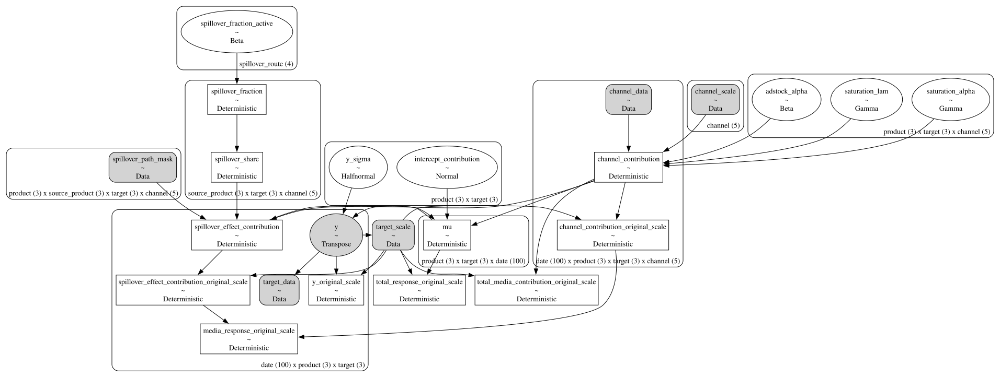

In [23]:
dims = ("product", "target")
media_dims = (*dims, "channel")
# Channel scale: mean spend over the weeks with spend, one number per channel.
channel_scale_values = channel_values.where(channel_values > 0).mean("date")

mmm = MMM(
    date_column="date",
    channel_columns=channels,
    target_column="y",
    dims=dims,
    adstock=GeometricAdstock(
        l_max=7, priors={"alpha": Prior("Beta", alpha=2, beta=2, dims=media_dims)}
    ),
    saturation=MichaelisMentenSaturation(
        priors={
            "alpha": Prior("Gamma", mu=0.25, sigma=0.25, dims=media_dims),
            "lam": Prior("Gamma", mu=1, sigma=0.5, dims=media_dims),
        }
    ),
    scaling={
        "channel": {
            "method": "fixed",
            "dims": dims,
            "value": {
                channel: float(channel_scale_values.sel(channel=channel))
                for channel in channels
            },
        },
        "target": {"method": "max", "dims": dims},
    },
    model_config={
        "intercept": Prior("Normal", mu=0.3, sigma=0.3, dims=dims),
        "likelihood": Prior(
            "Normal",
            sigma=Prior("HalfNormal", sigma=0.05, dims=dims),
            dims=("date", *dims),
        ),
    },
)
mmm.mu_effects.append(
    SpilloverEffect(
        path_mask=spill_mask,
        fraction_prior=Prior("Beta", alpha=2, beta=2, dims=SpilloverEffect.source_dims),
        max_share=0.5,
    )
)
mmm.build_model(X, y)
mmm.add_original_scale_contribution_variable(
    var=["channel_contribution", "spillover_effect_contribution", "y"]
)

with mmm.model:
    pmd.Deterministic(
        "media_response_original_scale",
        mmm.model["channel_contribution_original_scale"].sum(dim="channel")
        + mmm.model["spillover_effect_contribution_original_scale"],
        dims=("date", "product", "target"),
    )

pm.model_to_graphviz(mmm.model)

The graph has the `MMM`'s own blocks, the scaled data containers, the three media parameter blocks, `intercept_contribution` and `y_sigma`, plus the route: `spillover_fraction_active` with four entries, expanded to `spillover_share`, multiplied with the mask and the channel contribution and added to `mu`. Note the coordinate order: the `MMM` sorted `target` to `brand`, `consideration`, `sales`.

## Prior Predictive Checks

Before fitting, let's see what the priors allow. We draw outcomes from the prior and compare the bands with the observed series.

In [24]:
mmm.sample_prior_predictive(X, y, samples=500, random_seed=rng)

prior_outcome = mmm.idata.prior["y_original_scale"]
prior_outcome_hdi = az.hdi(prior_outcome.to_dataset(name="y"), prob=HDI_PROB)["y"]

Sampling: [adstock_alpha, intercept_contribution, saturation_alpha, saturation_lam, spillover_fraction_active, y, y_sigma]


The grid below has one panel per product and outcome.

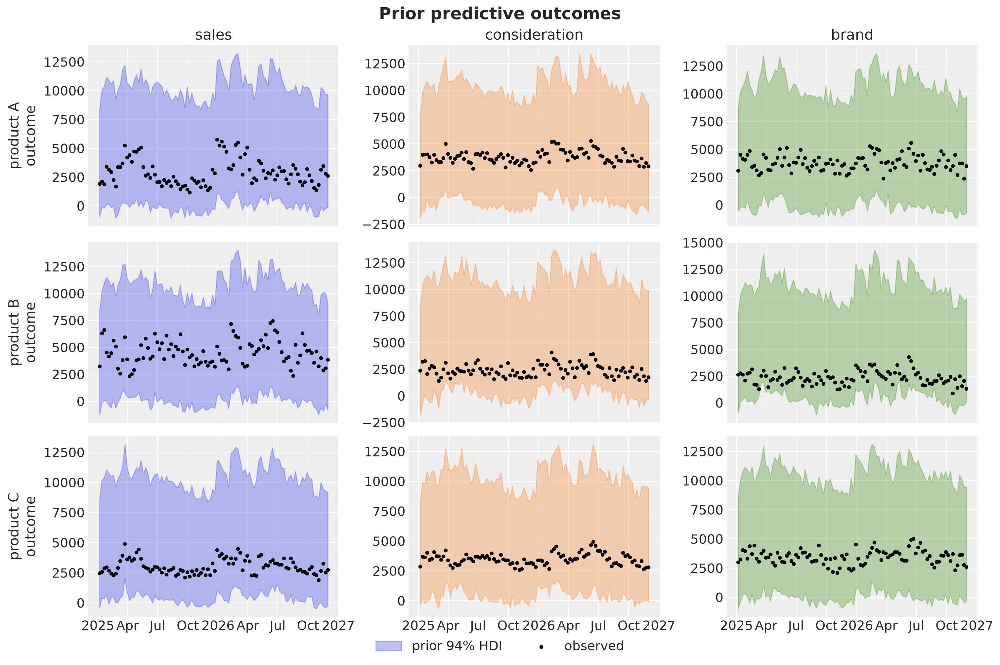

In [25]:
fig, axes = plt.subplots(
    nrows=len(products),
    ncols=len(targets),
    figsize=(15, 10),
    sharex=True,
    layout="constrained",
)

for row, product in enumerate(products):
    for col, target in enumerate(targets):
        ax = axes[row, col]
        selection = {"product": product, "target": target}
        ax.fill_between(
            dates,
            prior_outcome_hdi.sel(selection).sel(ci_bound="lower"),
            prior_outcome_hdi.sel(selection).sel(ci_bound="upper"),
            color=f"C{col}",
            alpha=0.3,
            label=r"prior $94\%$ HDI",
        )
        ax.scatter(
            dates, target_values.sel(selection), color="black", s=10, label="observed"
        )
        if row == 0:
            ax.set_title(target)
        if col == 0:
            ax.set_ylabel(f"{product}\noutcome")

for ax in axes[-1]:
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
    )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=2)
fig.suptitle("Prior predictive outcomes", fontsize=18, fontweight="bold");

The prior bands reach up to about $14{,}000$ while the observed series stay below $7{,}500$, and the bands cover every observed point. The priors allow outcomes about twice as large as anything observed, and also negative values for all nine series, since a Normal baseline and a Normal likelihood do not know that outcomes are positive. Nothing here is tuned to the data. That is the room we want before fitting.

## Model Fitting

We fit the model with four chains of `nutpie`. The `target_accept` of $0.95$ is a conservative choice: smaller steps cost a little sampling time, which is negligible for a model of this size, and make divergences less likely.

In [26]:
mmm.fit(
    X=X,
    y=y,
    draws=1_000,
    tune=1_000,
    chains=4,
    cores=4,
    nuts_sampler="nutpie",
    target_accept=0.95,
    random_seed=seed,
);

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_alpha, spillover_fraction_active, y_sigma, intercept_contribution]


Output()

Output()

## Model Diagnostics

Before looking into the results, let's check some diagnostics. We summarize all stochastic parameters in one row: the number of divergences, the largest $\hat{R}$ and the smallest effective sample sizes.

In [27]:
stochastic_parameters = [
    "adstock_alpha",
    "saturation_alpha",
    "saturation_lam",
    "intercept_contribution",
    "y_sigma",
    "spillover_fraction_active",
]
posterior_summary = az.summary(mmm.idata, var_names=stochastic_parameters)
diagnostics_overview = pd.DataFrame(
    {
        "divergences": [int(mmm.idata.sample_stats["diverging"].sum().item())],
        "max r_hat": [posterior_summary["r_hat"].max()],
        "min ess_bulk": [posterior_summary["ess_bulk"].min()],
        "min ess_tail": [posterior_summary["ess_tail"].min()],
    },
    index=pd.Index([f"{len(posterior_summary)} parameters"], name="scope"),
)
diagnostics_overview.round(3)

,divergences,max r_hat,min ess_bulk,min ess_tail
scope,,,,
157 parameters,1,1.01,1069,760


The sampler reports at most a divergence or two in $4{,}000$ draws, which is harmless at this scale, and the exact count can differ between machines because `nutpie` runs are not bit-for-bit repeatable. The largest $\hat{R}$ is $1.01$ and the smallest effective sample sizes are in the high hundreds or above for the $157$ parameters, which is good!

The four spillover shares are the parameters of interest. Recall that the true share is $0.4$ on all four routes. We compare the posterior with the prior in a forest plot, because the question is how much the data moved the shares. We write a small helper for that layout, one block of rows per label of `row_dim` and one colored row per label of `group_dim`, since the same layout serves the recovery checks and the policy comparisons later.

In [28]:
def forest_by_group(
    draws: xr.DataArray,
    group_dim: str,
    row_dim: str,
    title: str,
    xlabel: str,
    figsize: tuple[float, float] = (13, 6),
    reference: float | None = None,
    reference_label: str = "goal",
    colors: dict[str, str] | None = None,
) -> None:
    """Forest plot of ``draws`` with dims ``(group_dim, sample, row_dim)``.

    ``colors`` maps the labels of ``group_dim`` to colors, so that a group keeps its color across figures.
    """
    dataset = xr.Dataset(
        {
            str(label): draws.sel({row_dim: label}, drop=True)
            for label in draws[row_dim].values
        }
    )
    tree = xr.DataTree.from_dict({"/posterior": xr.DataTree(dataset)})
    color_cycle = (
        {}
        if colors is None
        else {"color": [colors[g] for g in draws[group_dim].values]}
    )
    plot_collection = azp.plot_forest(
        tree,
        sample_dims=["sample"],
        aes={"color": [group_dim]},
        labels=["__variable__"],
        backend="matplotlib",
        figure_kwargs={"figsize": figsize},
        **color_cycle,
    )
    plot_collection.add_legend(group_dim, loc="outside lower center", ncols=3)
    fig = plot_collection.viz["/"]["figure"].values.item()
    label_axis, plot_axis = fig.axes[0], fig.axes[-1]
    # The label column needs no ticks or grid, and a little room so the labels are not clipped.
    label_axis.set_xticks([])
    label_axis.set_xlim(-0.08, 1.0)
    label_axis.grid(False)

    if reference is not None:
        plot_axis.axvline(
            reference, color="black", linestyle="--", label=reference_label
        )
        plot_axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plot_axis.set_xlabel(xlabel)
    fig.suptitle(title, fontsize=18, fontweight="bold")

The prior draws come from the prior predictive step above, and we thin the posterior to the same number of draws.

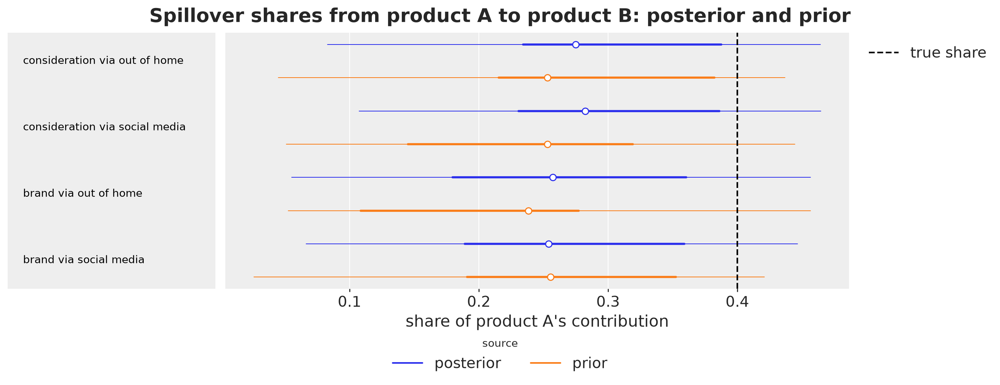

In [29]:
route_coords = {
    "source_product": "product A",
    "target": ["consideration", "brand"],
    "channel": ["out of home", "social media"],
}


def stack_routes(share: xr.DataArray) -> xr.DataArray:
    """Return the four active shares as a (sample, route) array."""
    routes = share.sel(route_coords, drop=True).stack(
        sample=("chain", "draw"), route=("target", "channel")
    )
    labels = [f"{target} via {channel}" for target, channel in routes["route"].values]
    return routes.drop_vars(
        ["chain", "draw", "sample", "route", "target", "channel"]
    ).assign_coords(route=labels)


# Every eighth posterior draw, to match the 500 prior draws.
share_draws = xr.concat(
    [
        stack_routes(mmm.idata.posterior["spillover_share"]).isel(
            sample=slice(0, None, 8)
        ),
        stack_routes(mmm.idata.prior["spillover_share"]),
    ],
    dim="source",
).assign_coords(source=["posterior", "prior"])

forest_by_group(
    share_draws,
    group_dim="source",
    row_dim="route",
    title="Spillover shares from product A to product B: posterior and prior",
    xlabel="share of product A's contribution",
    figsize=(13, 5),
    reference=true_spill_share,
    reference_label="true share",
)

The posterior sits almost on top of the prior for all four routes: the posterior means are between $0.25$ and $0.28$ against a prior mean of $0.25$, and the posterior intervals are about as wide as the prior ones, from below $0.1$ to about $0.46$. In other words, the data moved the shares very little, and the true share of $0.4$ sits in the upper part of the interval. We come back to this in the recovery section.

Let's also look at the traces of one slice, product A's `TV` parameters for `sales`.

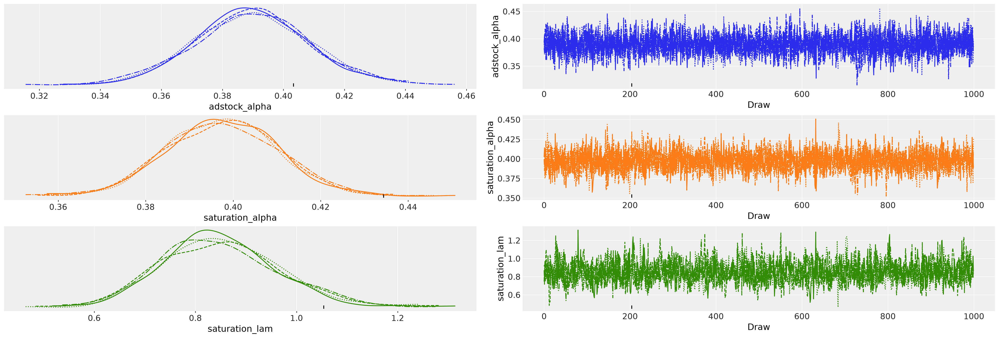

In [30]:
azp.plot_trace_dist(
    mmm.idata,
    var_names=["adstock_alpha", "saturation_alpha", "saturation_lam"],
    coords={"product": ["product A"], "channel": ["TV"], "target": ["sales"]},
    backend="matplotlib",
);

We see a good mixing in the traces, with the four chains on top of each other.

## Posterior Predictive Checks

As our model and posterior samples are looking good, we can now look into the posterior predictive checks. We sample the outcomes at the historical spend and compare them with the observations and with the true means we know from the generator.

In [31]:
mmm.sample_posterior_predictive(X, extend_idata=True, combined=False, random_seed=rng)

posterior_outcome = mmm.idata.posterior_predictive["y_original_scale"]
posterior_outcome_mean = posterior_outcome.mean(("chain", "draw"))
posterior_outcome_hdi = az.hdi(posterior_outcome.to_dataset(name="y"), prob=HDI_PROB)[
    "y"
]

Sampling: [y]


Output()

Same grid as before, now with the posterior predictive bands.

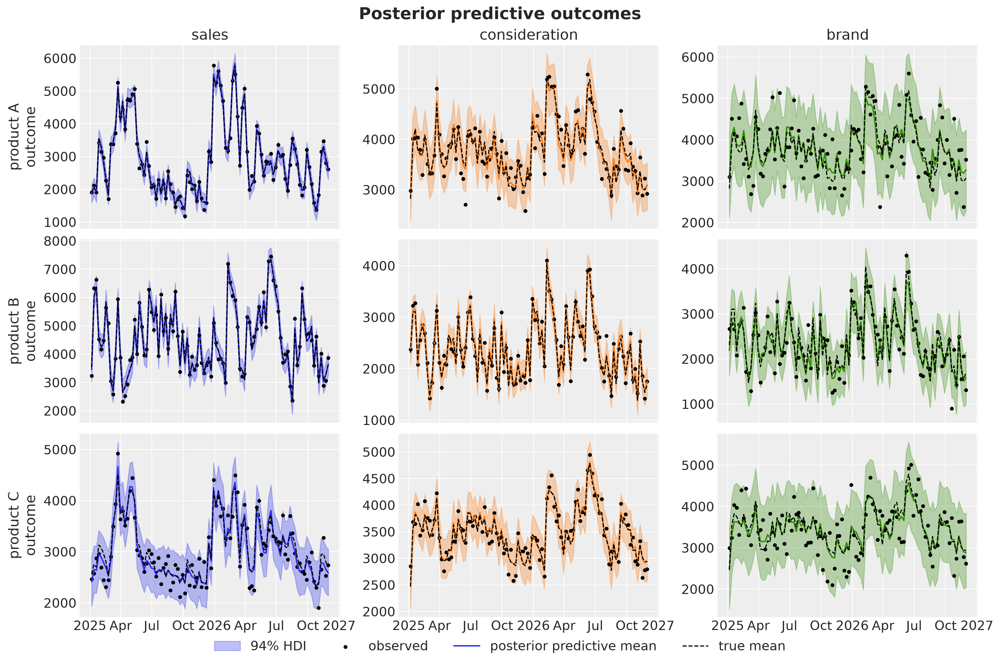

In [32]:
fig, axes = plt.subplots(
    nrows=len(products),
    ncols=len(targets),
    figsize=(15, 10),
    sharex=True,
    layout="constrained",
)

for row, product in enumerate(products):
    for col, target in enumerate(targets):
        ax = axes[row, col]
        selection = {"product": product, "target": target}
        ax.fill_between(
            dates,
            posterior_outcome_hdi.sel(selection).sel(ci_bound="lower"),
            posterior_outcome_hdi.sel(selection).sel(ci_bound="upper"),
            color=f"C{col}",
            alpha=0.3,
            label=r"$94\%$ HDI",
        )
        ax.scatter(
            dates, target_values.sel(selection), color="black", s=10, label="observed"
        )
        ax.plot(
            dates,
            posterior_outcome_mean.sel(selection),
            color=f"C{col}",
            label="posterior predictive mean",
        )
        ax.plot(
            dates,
            true_mu.sel(selection),
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="true mean",
        )
        if row == 0:
            ax.set_title(target)
        if col == 0:
            ax.set_ylabel(f"{product}\noutcome")

for ax in axes[-1]:
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
    )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=4)
fig.suptitle("Posterior predictive outcomes", fontsize=18, fontweight="bold");

The posterior predictive means follow the true means closely for all nine series, and the observed points fall inside the bands. The `brand` bands are about twice as wide as the `consideration` bands, which is the doubled observation noise by design. The posterior predictive outcomes look quite reasonable.

## Contribution Recovery

The posterior predictive checks say that the model reproduces the data. The real test is whether it recovers the quantities it was generated from. The model is correctly specified, so this is a test of identification from $100$ weeks of shared, noisy spend, not of the model class. We check three things: the total media response per product and outcome, the channel contributions for `sales`, and the spillover route.

### Media Response

`media_response_original_scale` is a product's own media plus its incoming spillover, in original units. We compare its posterior with the true own media plus the true spillover.

In [33]:
posterior_media_response = mmm.idata.posterior["media_response_original_scale"]
posterior_media_response_mean = posterior_media_response.mean(("chain", "draw"))
posterior_media_response_hdi = az.hdi(
    posterior_media_response.to_dataset(name="media"), prob=HDI_PROB
)["media"]
true_media_response = true_contribution.sum("channel") + true_spillover

One panel per product and outcome, with the truth as a dashed line.

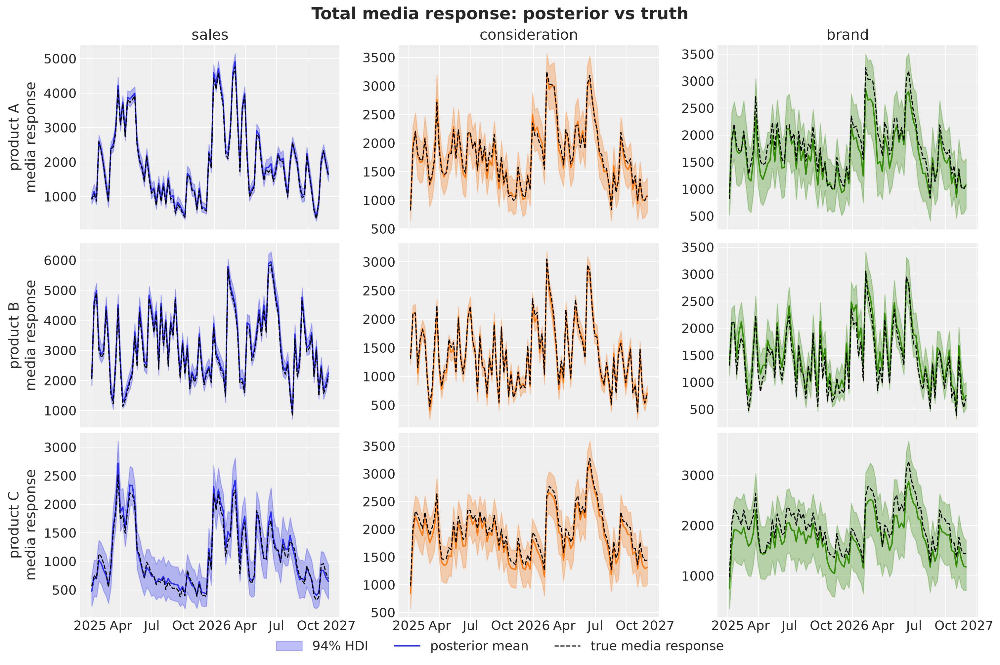

In [34]:
fig, axes = plt.subplots(
    nrows=len(products),
    ncols=len(targets),
    figsize=(15, 10),
    sharex=True,
    layout="constrained",
)

for row, product in enumerate(products):
    for col, target in enumerate(targets):
        ax = axes[row, col]
        selection = {"product": product, "target": target}
        ax.fill_between(
            dates,
            posterior_media_response_hdi.sel(selection).sel(ci_bound="lower"),
            posterior_media_response_hdi.sel(selection).sel(ci_bound="upper"),
            color=f"C{col}",
            alpha=0.3,
            label=r"$94\%$ HDI",
        )
        ax.plot(
            dates,
            posterior_media_response_mean.sel(selection),
            color=f"C{col}",
            label="posterior mean",
        )
        ax.plot(
            dates,
            true_media_response.sel(selection),
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="true media response",
        )
        if row == 0:
            ax.set_title(target)
        if col == 0:
            ax.set_ylabel(f"{product}\nmedia response")

for ax in axes[-1]:
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
    )

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
fig.suptitle(
    "Total media response: posterior vs truth", fontsize=18, fontweight="bold"
);

The dashed truth runs inside the band in all nine panels. The sales panels of products A and B are tight, the `brand` panels are the widest, about twice as wide as the `consideration` ones, and product C's sales band is wider than the other two sales bands because its channel effects are moderate everywhere and large nowhere. In the `brand` panels the posterior mean drifts below the truth for products A and C, most visibly at product A's flight peaks. The media response is the quantity the budget optimizer needs, and the model recovers it.

### Sales Channels

For `sales` there is no spillover, so every channel contribution is a quantity the data can identify. Rows are products, columns are channels.

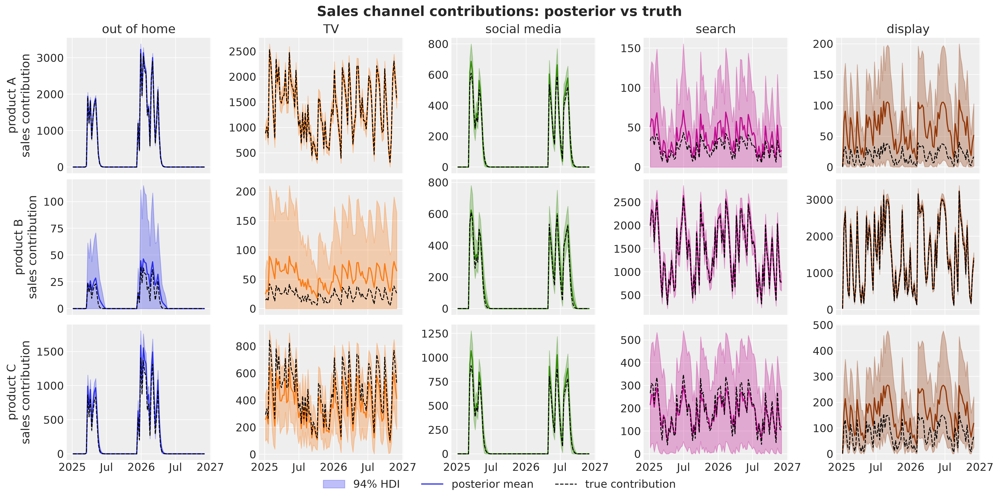

In [35]:
posterior_channel_contribution = mmm.idata.posterior[
    "channel_contribution_original_scale"
]
posterior_sales_contribution = posterior_channel_contribution.sel(target="sales")
posterior_sales_contribution_mean = posterior_sales_contribution.mean(("chain", "draw"))
posterior_sales_contribution_hdi = az.hdi(
    posterior_sales_contribution.to_dataset(name="contribution"), prob=HDI_PROB
)["contribution"]

fig, axes = plt.subplots(
    nrows=len(products),
    ncols=len(channels),
    figsize=(18, 9),
    sharex=True,
    layout="constrained",
)

for row, product in enumerate(products):
    for col, channel in enumerate(channels):
        ax = axes[row, col]
        selection = {"product": product, "channel": channel}
        ax.fill_between(
            dates,
            posterior_sales_contribution_hdi.sel(selection).sel(ci_bound="lower"),
            posterior_sales_contribution_hdi.sel(selection).sel(ci_bound="upper"),
            color=f"C{col}",
            alpha=0.3,
            label=r"$94\%$ HDI",
        )
        ax.plot(
            dates,
            posterior_sales_contribution_mean.sel(selection),
            color=f"C{col}",
            label="posterior mean",
        )
        ax.plot(
            dates,
            true_contribution.sel({**selection, "target": "sales"}),
            color="black",
            linestyle="--",
            linewidth=1.2,
            label="true contribution",
        )
        if row == 0:
            ax.set_title(channel)
        if col == 0:
            ax.set_ylabel(f"{product}\nsales contribution")

for ax in axes[-1]:
    # Two ticks a year, so that the labels of the narrow panels do not overlap.
    locator = mdates.MonthLocator(bymonth=(1, 7))
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
fig.suptitle(
    "Sales channel contributions: posterior vs truth", fontsize=18, fontweight="bold"
);

The channels that matter are recovered tightly: `out of home` and `TV` for product A, `search` and `display` for product B, and `social media` for all three products, where the flights give a clear signal. The bands are widest relative to the truth where the true effect is close to zero, `search` and `display` for product A and `out of home` and `TV` for product B, and there the posterior means sit a little above the truth. The model can only say that those contributions are small.

### Spillover Attribution

Now the route. Product B's `consideration` responds to `out of home` and `social media` in two ways: through its own curves and through the spillover from product A. Let's look at the weekly decomposition the model gives for these two channels, with the true total on top.

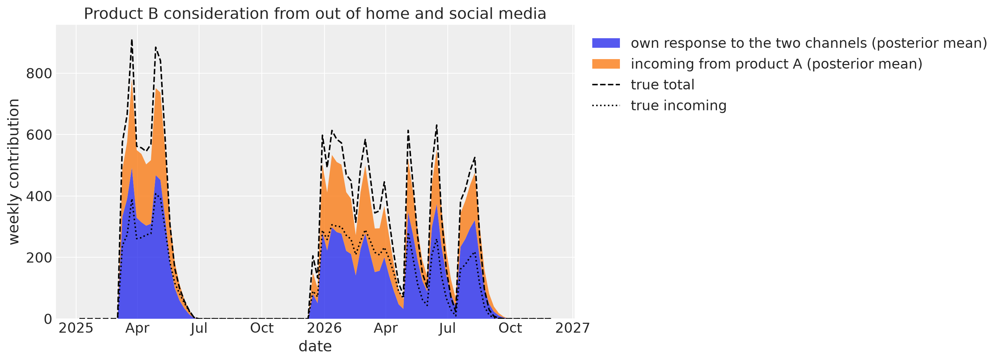

In [36]:
route_channels = ["out of home", "social media"]
route_selection = {"product": "product B", "target": "consideration"}

own_route_draws = posterior_channel_contribution.sel(
    {**route_selection, "channel": route_channels}
).sum("channel")
incoming_draws = mmm.idata.posterior[
    "spillover_effect_contribution_original_scale"
].sel(route_selection)
true_own_route = true_contribution.sel(
    {**route_selection, "channel": route_channels}
).sum("channel")
true_incoming = true_spillover.sel(route_selection)

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    dates,
    own_route_draws.mean(("chain", "draw")),
    incoming_draws.mean(("chain", "draw")),
    labels=[
        "own response to the two channels (posterior mean)",
        "incoming from product A (posterior mean)",
    ],
    colors=["C0", "C1"],
    alpha=0.8,
)
ax.plot(
    dates,
    true_own_route + true_incoming,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="true total",
)
ax.plot(
    dates,
    true_incoming,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="true incoming",
)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.set(
    title="Product B consideration from out of home and social media",
    xlabel="date",
    ylabel="weekly contribution",
)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0));

The stacked posterior means follow the shape of the true total through both flights but run low: about $10\%$ below the truth in the first flights, about $15\%$ below in the second `out of home` flight, and close to it in the second `social media` flight. The split is off as well: the model gives the larger part of the response to product B's own curves and the smaller part to the incoming spillover, while in the truth the two parts are about equal.

To compare the three quantities with their truth, we sum them over the $100$ weeks and show the posterior next to the true value with the same forest helper. The truth enters the plot as a second source with a single repeated value, so it shows up as a point.

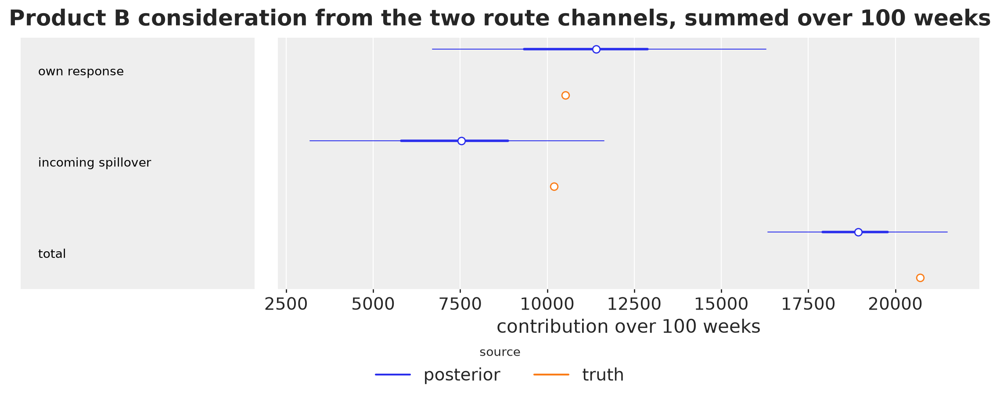

In [37]:
def over_weeks(
    posterior_draws: xr.DataArray, true_values: xr.DataArray
) -> xr.DataArray:
    """Stack posterior and truth of a weekly series summed over the weeks, dims (source, sample)."""
    posterior = (
        posterior_draws.sum("date")
        .stack(sample=("chain", "draw"))
        .drop_vars(["chain", "draw", "sample"])
    )
    truth = xr.full_like(posterior, float(true_values.sum("date")))
    return xr.concat([posterior, truth], dim="source").assign_coords(
        source=["posterior", "truth"]
    )


attribution_draws = xr.concat(
    [
        over_weeks(own_route_draws, true_own_route),
        over_weeks(incoming_draws, true_incoming),
        over_weeks(own_route_draws + incoming_draws, true_own_route + true_incoming),
    ],
    dim="quantity",
).assign_coords(quantity=["own response", "incoming spillover", "total"])

forest_by_group(
    attribution_draws,
    group_dim="source",
    row_dim="quantity",
    title="Product B consideration from the two route channels, summed over 100 weeks",
    xlabel="contribution over 100 weeks",
    figsize=(11, 4.5),
)

The same numbers as a table, with the truth in the last column.

In [38]:
def summarize_against_truth(draws: xr.DataArray, row_dim: str) -> pd.DataFrame:
    """Return mean, HDI and truth per row of a (source, sample, row_dim) array."""
    posterior = draws.sel(source="posterior")
    hdi = az.hdi(posterior.to_dataset(name="value"), prob=HDI_PROB, dim="sample")[
        "value"
    ]
    return pd.DataFrame(
        {
            "posterior mean": posterior.mean("sample"),
            "hdi lower": hdi.sel(ci_bound="lower", drop=True),
            "hdi upper": hdi.sel(ci_bound="upper", drop=True),
            "truth": draws.sel(source="truth").isel(sample=0),
        },
        index=pd.Index(draws[row_dim].values, name=row_dim),
    ).round(0)


summarize_against_truth(attribution_draws, row_dim="quantity")

,posterior mean,hdi lower,hdi upper,truth
quantity,,,,
own response,11404.0,6708.0,16289.0,10522.0
incoming spillover,7532.0,3184.0,11626.0,10189.0
total,18935.0,16334.0,21494.0,20711.0


The total over the $100$ weeks has a posterior mean of about $18{,}900$ with a $94\%$ HDI from about $16{,}300$ to $21{,}500$, and the truth of $20{,}711$ is inside it, in the upper part. The two parts are not recovered as well: the own response has a mean of about $11{,}400$ against a truth of $10{,}522$, and the incoming spillover a mean of about $7{,}500$ against a truth of $10{,}189$. Both intervals are wide and cover the truth, but their centers sit where the prior put them.

```{warning}
**Critical Assessment**: with shared spend, product B's own response to `out of home` and the spillover from product A's response to `out of home` are two curves of the same input. The data pin down their sum, not the split. The posterior of the share stays close to its prior, so a stakeholder who asks "how much of product B's consideration do we owe to product A's campaigns" gets the prior back. {ref}`mmm_halo` shows the setting where the split is identified, product-specific spend. For the shared budget below this does not matter: the plan depends on the total response to a channel, which the model recovers, and both parts of the split respond to the same spend.
```

## Budget Optimization

Now that we are happy with the model fit, we can plan the budget. We use the {class}`~pymc_marketing.mmm.budget_optimizer.BudgetOptimizer` with custom utilities and constraints, all built on the fitted posterior.

### Planning Model

The optimizer takes a PyMC model and replaces its `channel_data` container with the budgets it searches over. In the `MMM` that container has dims `(date, product, target, channel)`, so the optimizer would search over $45$ budgets, one per product, outcome and channel. Our spend is shared, so we hand the optimizer a planning copy of the model with one container of dims `(date, channel)` that is broadcast into the `MMM`'s own. The planning horizon is $7$ weeks of constant spend: with $7$ normalized adstock lags, the last week is exactly at steady state, so we optimize the response in that week.

```{note}
**How the planning copy works**: we clone the fitted model, resize its data to the horizon, add a `shared_channel_data` container, and use `pm.do` to replace `channel_data` by a broadcast of the shared container. We then tell the optimizer to treat `shared_channel_data` as the decision variable through `channel_data_var`.
```

In [39]:
horizon = mmm.adstock.l_max
planning_dates = pd.date_range(
    dates[-1] + pd.Timedelta(weeks=1), periods=horizon, freq="W-MON"
)

planning_model = clone_model(mmm.model)
with planning_model:
    # Resize the MMM containers to the planning horizon, (date, product, target, channel) and (date, product, target).
    pm.set_data(
        {
            "channel_data": np.zeros(
                (horizon, len(products), len(targets), len(channels))
            ),
            "target_data": np.zeros((horizon, len(products), len(targets))),
        },
        coords={"date": planning_dates},
    )
    # One shared spend container, (date, channel), broadcast to the MMM's container.
    shared_spend = pmd.Data(
        "shared_channel_data",
        np.zeros((horizon, len(channels))),
        dims=("date", "channel"),
    )
    broadcast_spend = shared_spend.expand_dims(
        product=len(products), target=len(targets)
    ).transpose("date", "product", "target", "channel")

planning_model = pm.do(planning_model, {"channel_data": broadcast_spend})
all_channels = xr.DataArray(
    np.ones(len(channels), dtype=bool), dims="channel", coords={"channel": channels}
)

# The MMM sorts coordinate labels, so we select products and outcomes by position from its coordinates.
product_index = {
    product: list(mmm.model.coords["product"]).index(product) for product in products
}
target_index = {
    target: list(mmm.model.coords["target"]).index(target) for target in targets
}

### Five Priorities

Every plan below spends the same $5{,}000$ per week across the five channels. What differs is the business priority:

| Policy | Maximizes | Products |
|---|---|---|
| Product A sales | expected media-driven sales | product A only |
| Product B sales | expected media-driven sales | product B only |
| Total consideration | expected consideration, own plus incoming spillover, summed over products | all three |
| Total brand | expected brand, own plus incoming spillover, summed over products | all three |
| Balanced sales | the smallest fraction of each product's own best sales (max-min) | all three |

These are five different questions, not five estimates of the same thing. The point of the exercise is to see how much each priority costs the others. Two remarks on the list. First, the totals add `consideration` and `brand` across products without normalizing, unlike the sales frontier. That is a question of units: the two survey outcomes are counts in one panel, so one consideration event for product A is the same event as one for product C, and the total is the number of such events the portfolio buys. The sales frontier divided by the ideals because we wanted fairness between products of different sizes, not because sales could not be added. Second, product C gets no single-product policy. Its channels are a blend of the other two products', so its plan is not a corner and adds little to the comparison. We compute its ideal below because the max-min rule needs it.

A utility receives the symbolic response `samples` and the symbolic `budgets` and returns the scalar to maximize. We use `media_response_original_scale` as the response for every utility: it has dims `(sample, date, product, target)`, the posterior draws come first, and for `sales` it equals the channel contributions because no route touches sales. Symbolic tensors know dimension names but not labels, so we select by position. First, the single-product sales utilities.

In [40]:
def expected_response(
    samples: XTensorVariable, product: str, target: str
) -> XTensorVariable:
    """Return the posterior-mean final-week media response of one product and outcome."""
    return samples.isel(
        date=-1, product=product_index[product], target=target_index[target]
    ).mean(dim="sample")


def maximize_product_b_sales(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return product B's expected sales."""
    return expected_response(samples, "product B", "sales")


def maximize_product_a_sales(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return product A's expected sales."""
    return expected_response(samples, "product A", "sales")


def maximize_product_c_sales(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return product C's expected sales (only used as the third ideal of the balanced policy)."""
    return expected_response(samples, "product C", "sales")

Next, the two total utilities, which sum over products before averaging over draws.

In [41]:
def maximize_total_consideration(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return expected consideration summed over all products."""
    return (
        samples.isel(date=-1, target=target_index["consideration"])
        .sum(dim="product")
        .mean(dim="sample")
    )


def maximize_total_brand(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return expected brand summed over all products."""
    return (
        samples.isel(date=-1, target=target_index["brand"])
        .sum(dim="product")
        .mean(dim="sample")
    )

Finally, a runner. We solve each problem from six starting points, equal spend and the five channel corners, and keep the best run that respects the budget. The objectives are concave in the budget, so all starts should agree, and the table of runs is a cheap check that they do.

In [42]:
starting_allocations = np.vstack(
    [
        np.full(len(channels), weekly_budget / len(channels)),
        weekly_budget * np.eye(len(channels)),
    ]
)
start_names = ["equal spend", *[f"all {channel}" for channel in channels]]
# SLSQP's absolute tolerance has to match the scale of the response.
minimize_kwargs = {
    "method": "SLSQP",
    "options": {"ftol": 1e-9 * unit_scale, "maxiter": 2_000},
}
budget_tolerance = 1e-6


def budget_is_feasible(allocation: np.ndarray, total_budget: float) -> bool:
    """Check that an allocation is non-negative, within bounds, and sums to the budget."""
    return bool(
        np.isfinite(allocation).all()
        and (allocation >= -budget_tolerance).all()
        and (allocation <= total_budget + budget_tolerance).all()
        and abs(allocation.sum() - total_budget) <= budget_tolerance
    )


def maximize_utility(
    utility_function: Callable[[XTensorVariable, XTensorVariable], XTensorVariable],
) -> tuple[BudgetOptimizationResult, pd.DataFrame, BudgetOptimizer]:
    """Run the optimizer from every start and keep the best feasible solution."""
    optimizer = BudgetOptimizer(
        model=planning_model,
        idata=mmm.idata,
        num_periods=horizon,
        channel_data_var="shared_channel_data",
        budgets_to_optimize=all_channels,
        response_variable="media_response_original_scale",
        utility_function=utility_function,
    )
    runs = [
        optimizer.allocate_budget(
            total_budget=weekly_budget,
            budget_bounds={channel: (0.0, weekly_budget) for channel in channels},
            x0=start,
            minimize_kwargs=minimize_kwargs,
            return_if_fail=True,
        )
        for start in starting_allocations
    ]
    records = pd.DataFrame(
        {
            "start": start_names,
            "success": [run.scipy_result.success for run in runs],
            "feasible": [
                budget_is_feasible(run.budgets.values, weekly_budget) for run in runs
            ],
            "utility": [-run.scipy_result.fun for run in runs],
        }
    ).set_index("start")
    feasible_runs = [
        run for run, ok in zip(runs, records["feasible"], strict=True) if ok
    ]
    if not feasible_runs:
        raise RuntimeError(
            f"No start produced a feasible budget for {utility_function.__name__}."
        )

    return min(feasible_runs, key=lambda run: run.scipy_result.fun), records, optimizer

Let's run the four single-objective policies.

In [43]:
priority_utilities = {
    "Product A sales": maximize_product_a_sales,
    "Product B sales": maximize_product_b_sales,
    "Total consideration": maximize_total_consideration,
    "Total brand": maximize_total_brand,
}
priority_results = {}
priority_runs = {}
priority_optimizers = {}

for policy, utility_function in priority_utilities.items():
    priority_results[policy], priority_runs[policy], priority_optimizers[policy] = (
        maximize_utility(utility_function)
    )

pd.concat(priority_runs, names=["policy"])["utility"].unstack("start").round(1)

start,equal spend,all out of home,all TV,all social media,all search,all display
policy,,,,,,
Product A sales,5603.8,5603.8,5603.8,5603.8,5603.8,5603.8
Product B sales,5545.5,5545.5,5545.5,5545.5,5545.5,5545.5
Total consideration,8646.2,8646.2,8646.2,8646.2,8646.2,8646.2
Total brand,8162.7,8162.7,8162.7,8162.7,8162.7,8162.7


Every start reaches the same utility for each policy, to the first decimal. The problems are concave, so this is what we expect, and it tells us these four plans are global optima and not local ones.

### Balanced Policy

The max-min rule needs each product's ideal $I_p$, its best expected sales when the whole budget serves it alone. Product A's and product B's ideals are the two single-product policies above. Product C's comes from one more optimization that we do not show as a policy.

We then reuse `balanced_product_allocation` with the full stack of posterior draws for the sales parameters. The `MMM` stores $\alpha$ in units of the largest outcome and $\lambda$ in units of each channel's scale, its mean active-week spend, so the steady-state response in original units is $s_y\,\alpha\,b / (s_c\,\lambda + b)$. The response is evaluated in every draw and averaged, so the criterion is the smallest *posterior-mean* attainment, not a probability guarantee. As a consistency check, the closed form at the single-product optima has to match the optimizer's own objective values.

```{note}
**Why not the `BudgetOptimizer`?** The max-min objective is a minimum over products, which is not smooth, and the trick that makes it smooth adds a decision variable, the attainment level $t$, that the optimizer's utility interface has no slot for. The closed form keeps the problem exact and small. A smooth stand-in such as a soft minimum, a scaled log-sum-exp of the attainments, would fit the utility interface at the price of an approximation.
```

In [44]:
target_scale = float(mmm.model["target_scale"].get_value())
channel_scale = xr.DataArray(
    mmm.model["channel_scale"].get_value(), dims="channel", coords={"channel": channels}
)


def stack_sales_draws(parameter: xr.DataArray) -> np.ndarray:
    """Return the sales slice of a posterior parameter as a ``(sample, product, channel)`` array."""
    return (
        parameter.sel(target="sales", product=products, channel=channels)
        .stack(sample=("chain", "draw"))
        .transpose("sample", "product", "channel")
        .values
    )


# Closed-form parameters in original units: A' = s_y * alpha, lambda' = s_c * lambda.
sales_maximum = stack_sales_draws(
    target_scale * mmm.idata.posterior["saturation_alpha"]
)
sales_half_saturation = stack_sales_draws(
    channel_scale * mmm.idata.posterior["saturation_lam"]
)

product_c_result, _, _ = maximize_utility(maximize_product_c_sales)
single_product_results = {
    "product A": priority_results["Product A sales"],
    "product B": priority_results["Product B sales"],
    "product C": product_c_result,
}
sales_ideals = xr.DataArray(
    [
        product_response_and_gradient(
            single_product_results[product].budgets.sel(channel=channels).values,
            sales_maximum,
            sales_half_saturation,
        )[0][product_index[product]]
        for product in products
    ],
    dims="product",
    coords={"product": products},
    name="ideal sales",
)

# The closed form must reproduce the optimizer's objective at its own solution.
for product, result in single_product_results.items():
    np.testing.assert_allclose(
        sales_ideals.sel(product=product), -result.scipy_result.fun, rtol=1e-6
    )

balance_candidates = []

for start in starting_allocations:
    allocation, score = balanced_product_allocation(
        sales_maximum, sales_half_saturation, sales_ideals.values, start, weekly_budget
    )
    if budget_is_feasible(allocation, weekly_budget):
        balance_candidates.append((allocation, score))

balanced_budget, balance_score = max(
    balance_candidates, key=lambda candidate: candidate[1]
)

priority_names = [*priority_utilities, "Balanced sales"]
priority_allocations = (
    xr.concat(
        [
            priority_results[policy].budgets.sel(channel=channels)
            for policy in priority_utilities
        ]
        + [xr.DataArray(balanced_budget, dims="channel", coords={"channel": channels})],
        dim="policy",
    )
    .assign_coords(policy=priority_names)
    .transpose("policy", "channel")
)
weekly_allocation = priority_allocations.sel(policy="Balanced sales", drop=True)

# One color per policy, kept across every figure below.
policy_colors = {
    "Product A sales": "C0",
    "Product B sales": "C1",
    "Total consideration": "C2",
    "Total brand": "C3",
    "Balanced sales": "C4",
    "Cheapest for product B goals": "C5",
}

Let's look at the three ideals, the denominators of the balanced policy.

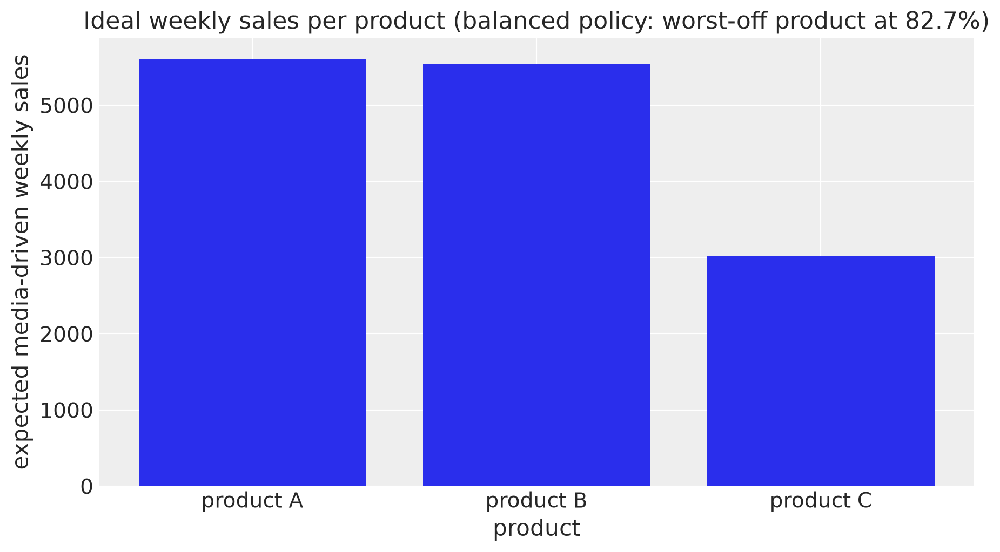

In [45]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(products, sales_ideals.values, color="C0")
ax.set(
    title=f"Ideal weekly sales per product (balanced policy: worst-off product at {balance_score:.1%})",
    xlabel="product",
    ylabel="expected media-driven weekly sales",
);

Products A and B can each reach about $5{,}600$ in weekly sales with the whole budget, product C only about $3{,}000$. The balanced policy brings the worst-off products, A and B, to about $83\%$ of their ideals, and product C sits higher, at about $88\%$, as it did under the true parameters.

### Policy Comparison

We score all five plans with the optimizer's own response graph, draw by draw, so that every policy is judged on the same posterior. The helper returns the final-week media response with dims `(sample, product, target)`.

In [46]:
# Every optimizer built on the planning model shares the same response graph, so any of them can score a plan.
plan_scorer = priority_optimizers["Product A sales"]


def score_plan(plan: xr.DataArray) -> xr.DataArray:
    """Return the final-week media response under a weekly plan, dims (sample, product, target)."""
    return plan_scorer.evaluate_response_distribution(
        plan, "media_response_original_scale"
    ).isel(date=-1)


policy_response = xr.concat(
    [score_plan(priority_allocations.sel(policy=policy)) for policy in priority_names],
    dim="policy",
).assign_coords(policy=priority_names)
policy_response_mean = policy_response.mean("sample")

# Score every policy on the five objectives.
policy_scores = pd.DataFrame(
    {
        "Product A sales": policy_response_mean.sel(
            product="product A", target="sales"
        ),
        "Product B sales": policy_response_mean.sel(
            product="product B", target="sales"
        ),
        "Total consideration": policy_response_mean.sel(target="consideration").sum(
            "product"
        ),
        "Total brand": policy_response_mean.sel(target="brand").sum("product"),
        "Min sales attainment (%)": 100
        * (
            policy_response_mean.sel(target="sales", product=products) / sales_ideals
        ).min("product"),
    },
    index=pd.Index(priority_names, name="policy"),
)

# Each single-objective policy must score its own objective at the optimizer's value.
for policy, result in priority_results.items():
    np.testing.assert_allclose(
        policy_scores.loc[policy, policy], -result.scipy_result.fun, rtol=1e-6
    )

np.testing.assert_allclose(
    policy_scores.loc["Balanced sales", "Min sales attainment (%)"],
    100 * balance_score,
    rtol=1e-6,
)

First, where each policy puts the money.

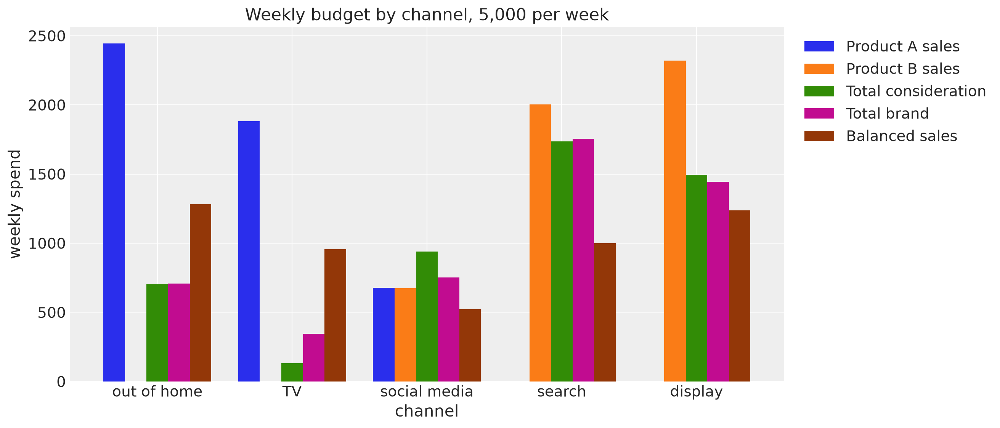

In [47]:
fig, ax = plt.subplots(figsize=(13, 5.5))
priority_allocations.to_pandas().T.plot.bar(
    ax=ax, rot=0, width=0.8, color=[policy_colors[policy] for policy in priority_names]
)

ax.set(
    title=f"Weekly budget by channel, {weekly_budget:,.0f} per week",
    xlabel="channel",
    ylabel="weekly spend",
)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0));

The two single-product policies are corners: `Product A sales` puts about $2{,}450$ on `out of home` and $1{,}900$ on `TV` and nothing on `search` or `display`, and `Product B sales` puts about $2{,}000$ on `search` and $2{,}300$ on `display` and nothing on `out of home` or `TV`. The two total policies agree on `search` and `display`, with about $1{,}750$ and $1{,}450$ each, but not on `TV`, where the brand plan spends about $340$ against about $130$ for the consideration plan. The balanced plan spreads the money, with $950$ to $1{,}300$ on each of the four sales channels.

Next, every policy scored on every objective. Each policy wins its own panel by construction, so the interesting part is the other panels.

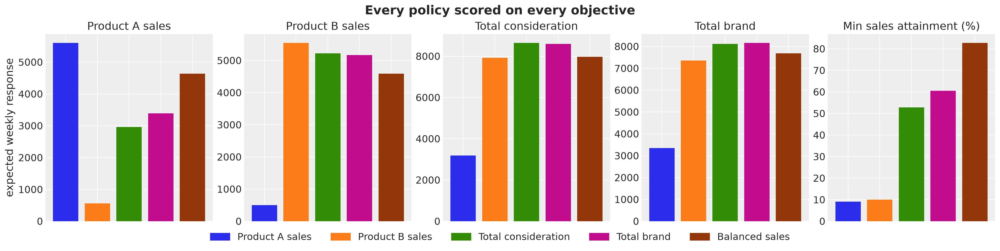

In [48]:
fig, axes = plt.subplots(
    nrows=1, ncols=len(policy_scores.columns), figsize=(20, 5), layout="constrained"
)

for ax, objective in zip(axes, policy_scores.columns, strict=True):
    ax.bar(
        range(len(priority_names)),
        policy_scores[objective],
        color=[policy_colors[policy] for policy in priority_names],
    )
    ax.set(title=objective, xticks=range(len(priority_names)), xticklabels=[])

axes[0].set_ylabel("expected weekly response")
handles = [
    plt.Rectangle((0, 0), 1, 1, color=policy_colors[policy])
    for policy in priority_names
]
fig.legend(handles, priority_names, loc="outside lower center", ncols=5)
fig.suptitle("Every policy scored on every objective", fontsize=18, fontweight="bold");

The corners are expensive for the other product: `Product A sales` leaves product B at about $500$ weekly sales, under $10\%$ of its ideal, and `Product B sales` leaves product A at about $560$, about $10\%$. The two total policies are interchangeable on the totals, where they differ by less than $1\%$, but they are not the same plan: the brand plan's extra `TV` spend gives product A about $3{,}400$ in sales against $3{,}000$ under the consideration plan, and lifts the worst-off product from $53\%$ to $60\%$ of its ideal. The brand plan is also estimated from data with twice the noise: its best total brand is about $6\%$ below the best total consideration, although the two true curves are identical, and its intervals are about $1.8$ times wider. The balanced policy gives up about $17\%$ of products A's and B's best sales, $4{,}590$ instead of $5{,}550$ for product B, and about $12\%$ of product C's, and about $8\%$ of the best total consideration, in exchange for lifting the worst-off product from under $10\%$ to about $83\%$ of its potential.

The forest plot adds the uncertainty: product sales under each policy, with the $94\%$ HDI.

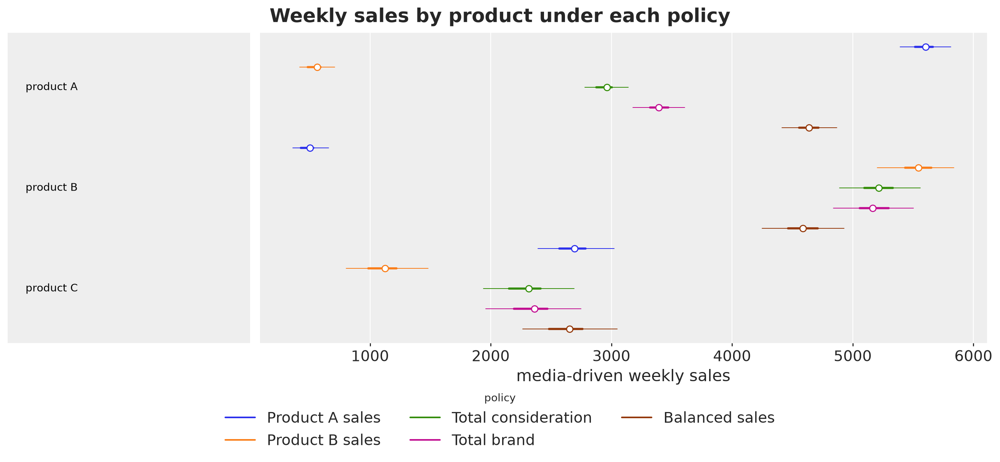

In [49]:
forest_by_group(
    policy_response.sel(target="sales", product=products),
    group_dim="policy",
    row_dim="product",
    title="Weekly sales by product under each policy",
    xlabel="media-driven weekly sales",
    colors=policy_colors,
)

The posterior of a neglected product under a corner policy does not overlap with any other policy: product B under `Product A sales` sits around $500$, far from the $4{,}600$ to $5{,}600$ of the other four plans. The two total policies and the balanced policy overlap for product C, whose intervals are the widest because its channel effects are the least well identified.

And the two totals.

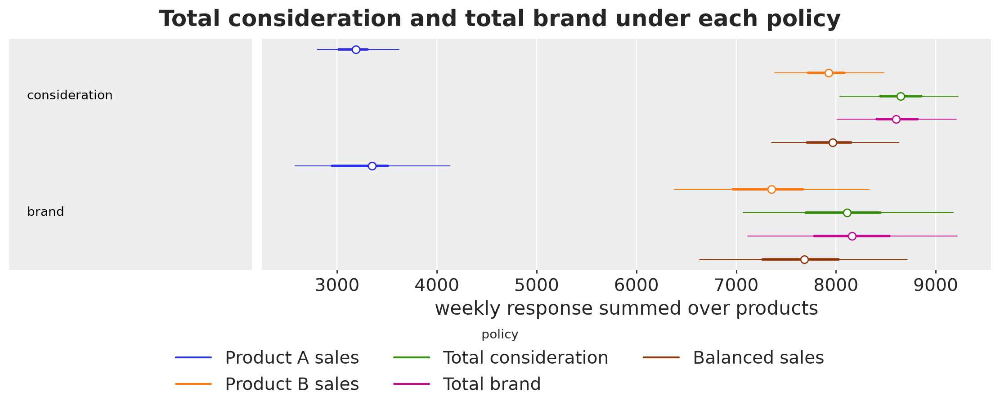

In [50]:
forest_by_group(
    policy_response.sel(target=["consideration", "brand"]).sum("product"),
    group_dim="policy",
    row_dim="target",
    title="Total consideration and total brand under each policy",
    xlabel="weekly response summed over products",
    figsize=(11, 4.5),
    colors=policy_colors,
)

The `Total consideration` and `Total brand` posteriors sit on top of each other for both totals, and the `Balanced sales` and `Product B sales` plans are $500$ to $800$ below them. Only the `Product A sales` corner is far off, because product A's channels do little for consideration.

**Business Value**: the comparison puts a price on each priority. A product manager who wants a corner plan can see what it costs the other products, and the balanced plan has a number attached to what it gives up in exchange for protecting everyone.

We keep the balanced allocation as `weekly_allocation`. It is the plan we would take to the next step if the question stopped here.

### Goal-Seeking Plans

The last question turns the problem around. Instead of "what is the best use of $5{,}000$", a stakeholder may ask "what is the least we can spend and still reach our goals for product B". Following the target-seeking example in {ref}`mmm_budget_allocation_example`, we minimize weekly spend subject to two goals on expected outcomes and a spending cap:

$$
\min_{b_c \geq 0}\ \sum_c b_c
\qquad\text{s.t.}\qquad
\mathbb{E}[\text{sales}_{B}(b)] \geq g_{\text{sales}},
\qquad
\mathbb{E}[\text{consideration}_{B}(b)] \geq g_{\text{cons}},
\qquad
\sum_c b_c \leq \text{cap}.
$$

Both outcomes are final-week media responses, so product B's consideration includes the incoming spillover. The goals constrain posterior means, not every draw. To make them concrete we set them at $90\%$ of what the balanced plan delivers for product B, rounded down to the nearest hundred, which gives $4{,}100$ for sales and $2{,}100$ for consideration in this run.

In [51]:
def round_down_to_hundreds(value: float) -> float:
    """Round a positive amount down to the nearest hundred."""
    return float(np.floor(value / 100.0) * 100.0)


balanced_product_b = policy_response_mean.sel(
    policy="Balanced sales", product="product B"
)
sales_goal = round_down_to_hundreds(0.9 * balanced_product_b.sel(target="sales").item())
consideration_goal = round_down_to_hundreds(
    0.9 * balanced_product_b.sel(target="consideration").item()
)
goals = pd.Series(
    {"sales": sales_goal, "consideration": consideration_goal}, name="product B goal"
)
goals.to_frame()

,product B goal
sales,4100.0
consideration,2100.0


The optimizer takes the goals as `Constraint` objects. Passing any custom constraint switches off the default "spend the whole budget" constraint, which is what we want here: the cap is a ceiling, not an amount to spend. The utility is minus the total spend.

In [52]:
def product_b_sales_goal(budgets_sym, total_budget_sym, optimizer) -> XTensorVariable:
    """Require expected product B sales to reach the goal."""
    response = optimizer.extract_response_distribution("media_response_original_scale")
    return expected_response(response, "product B", "sales") - sales_goal


def product_b_consideration_goal(
    budgets_sym, total_budget_sym, optimizer
) -> XTensorVariable:
    """Require expected product B consideration to reach the goal."""
    response = optimizer.extract_response_distribution("media_response_original_scale")
    return (
        expected_response(response, "product B", "consideration") - consideration_goal
    )


def spending_cap(budgets_sym, total_budget_sym, optimizer) -> XTensorVariable:
    """Keep weekly spend at or below the cap, which we pass as ``total_budget``."""
    return total_budget_sym - budgets_sym.sum(dim="channel")


def minimum_spend(
    samples: XTensorVariable, budgets: XTensorVariable
) -> XTensorVariable:
    """Return minus the weekly spend, so that maximizing it minimizes the spend."""
    return -budgets.sum(dim="channel")


cap_constraint = Constraint(
    key="cap", constraint_type="ineq", constraint_fun=spending_cap
)
consideration_constraint = Constraint(
    key="consideration goal",
    constraint_type="ineq",
    constraint_fun=product_b_consideration_goal,
)
sales_constraint = Constraint(
    key="sales goal", constraint_type="ineq", constraint_fun=product_b_sales_goal
)

A failed solve is not evidence that a goal is out of reach. So we proceed in three steps and declare a goal unreachable only when the *maximum* attainable value falls short of it: first the most consideration product B can get under the cap, then the most sales it can get while meeting the consideration goal, and only then the cheapest plan. The two maximizations also give feasible starting points. We build the three optimizers on the same planning model.

In [53]:
goal_optimizer_settings = {
    "model": planning_model,
    "idata": mmm.idata,
    "num_periods": horizon,
    "channel_data_var": "shared_channel_data",
    "budgets_to_optimize": all_channels,
    "response_variable": "media_response_original_scale",
}
most_consideration_optimizer = BudgetOptimizer(
    **goal_optimizer_settings,
    utility_function=lambda samples, budgets: expected_response(
        samples, "product B", "consideration"
    ),
    constraints=[cap_constraint],
)
most_sales_optimizer = BudgetOptimizer(
    **goal_optimizer_settings,
    utility_function=maximize_product_b_sales,
    constraints=[cap_constraint, consideration_constraint],
)
minimum_spend_optimizer = BudgetOptimizer(
    **goal_optimizer_settings,
    utility_function=minimum_spend,
    constraints=[cap_constraint, consideration_constraint, sales_constraint],
)

The runner below tries every start and keeps the best run under the cap.

In [54]:
def best_run(
    optimizer: BudgetOptimizer, cap: float, starts: list[np.ndarray]
) -> BudgetOptimizationResult:
    """Run the optimizer from every start under the cap and return the best run within the cap."""
    runs = [
        optimizer.allocate_budget(
            total_budget=cap,
            budget_bounds={channel: (0.0, cap) for channel in channels},
            x0=start,
            minimize_kwargs=minimize_kwargs,
            return_if_fail=True,
        )
        for start in starts
    ]
    within_cap = [
        run
        for run in runs
        if np.isfinite(run.scipy_result.fun)
        and (run.budgets.values >= -budget_tolerance).all()
        and run.budgets.values.sum() <= cap + budget_tolerance
    ]
    if not within_cap:
        raise RuntimeError(f"No start stayed within the cap of {cap:,.0f}.")

    return min(within_cap, key=lambda run: run.scipy_result.fun)


def cheapest_plan(cap: float) -> dict:
    """Find the minimum spend reaching both goals under a cap, or show which goal is out of reach."""
    starts = list(starting_allocations * cap / weekly_budget)
    record = {
        "cap": cap,
        "reachable consideration": np.nan,
        "reachable sales": np.nan,
        "spend": np.nan,
    }
    # 1. The most consideration product B can get under the cap alone.
    most_consideration = best_run(most_consideration_optimizer, cap, starts)
    record["reachable consideration"] = -most_consideration.scipy_result.fun
    if record["reachable consideration"] < consideration_goal * (1 - 1e-6):
        record["status"] = "consideration goal out of reach"
        return record

    # 2. The most sales product B can get while meeting the consideration goal.
    most_sales = best_run(
        most_sales_optimizer, cap, [*starts, most_consideration.budgets.values]
    )
    record["reachable sales"] = -most_sales.scipy_result.fun
    if record["reachable sales"] < sales_goal * (1 - 1e-6):
        record["status"] = "sales goal out of reach"
        return record

    # 3. The cheapest plan that meets both goals.
    cheapest = best_run(
        minimum_spend_optimizer, cap, [*starts, most_sales.budgets.values]
    )
    record.update(status="both goals reached", spend=cheapest.scipy_result.fun)
    record["allocation"] = cheapest.budgets.sel(channel=channels)
    return record

We solve it twice: with a loose cap of $10{,}000$, which should not bind, and with a tight cap of $1{,}600$, well below the cheapest plan, to see how an unreachable goal is reported.

In [55]:
loose = cheapest_plan(cap=10.0 * unit_scale)
tight = cheapest_plan(cap=1.6 * unit_scale)
goal_scenarios = pd.DataFrame(
    [
        {key: value for key, value in scenario.items() if key != "allocation"}
        for scenario in (loose, tight)
    ],
    index=pd.Index(["loose cap", "tight cap"], name="scenario"),
)
goal_scenarios["consideration goal"] = consideration_goal
goal_scenarios["sales goal"] = sales_goal
goal_scenarios.round(0)

,cap,reachable consideration,reachable sales,spend,status,consideration goal,sales goal
scenario,,,,,,,
loose cap,10000.0,3488.0,6487.0,3048.0,both goals reached,2100.0,4100.0
tight cap,1600.0,1412.0,NaN,NaN,consideration goal out of reach,2100.0,4100.0


Under the loose cap the cheapest plan spends about $3{,}050$ per week and reaches both goals. The most consideration product B can get under that cap is about $3{,}500$, and the most sales it can get while also meeting the consideration goal is about $6{,}500$, so the goals of $2{,}100$ and $4{,}100$ are comfortably inside what the budget can buy. Under the tight cap of $1{,}600$ the most consideration product B can get is about $1{,}400$, below the goal, so the table reports the consideration goal as out of reach and there is no plan to show. At that budget the stakeholder has to relax a goal or the cap.

Let's look at the cheapest plan.

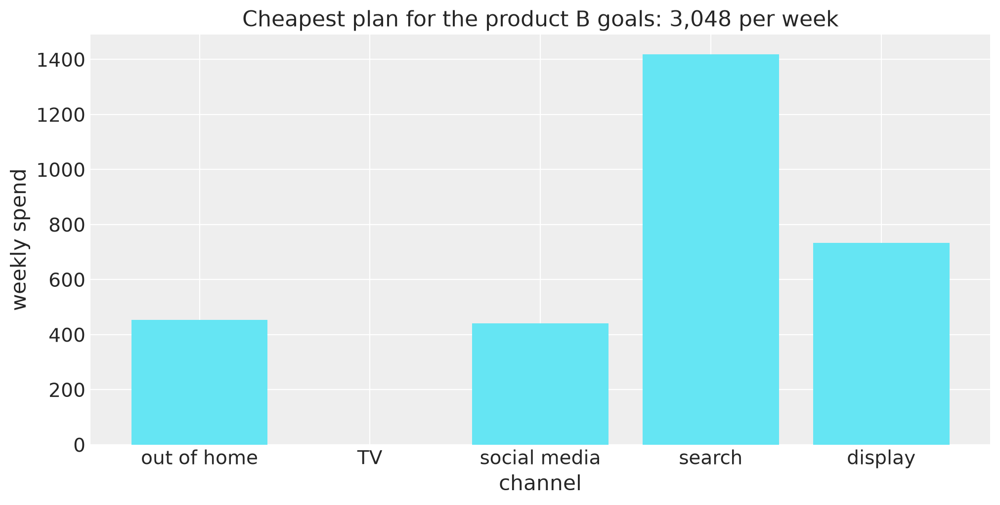

In [56]:
cheapest_allocation = loose["allocation"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    channels,
    cheapest_allocation.values,
    color=policy_colors["Cheapest for product B goals"],
)
ax.set(
    title=f"Cheapest plan for the product B goals: {loose['spend']:,.0f} per week",
    xlabel="channel",
    ylabel="weekly spend",
);

The cheapest plan spends about $3{,}050$ per week, $39\%$ less than the balanced plan's $5{,}000$. Almost half of it goes to `search`, about $1{,}400$, and a quarter to `display`, product B's own sales channels, with about $450$ each on `out of home` and `social media`, the two channels that also feed product B's consideration through the spillover route, and nothing on `TV`.

### Product B Plans

Finally we score three plans on product B's outcomes: the balanced plan, the total-consideration plan and the cheapest plan.

In [57]:
plan_names = ["Balanced sales", "Total consideration", "Cheapest for product B goals"]
plan_allocations = xr.concat(
    [
        weekly_allocation,
        priority_allocations.sel(policy="Total consideration", drop=True),
        cheapest_allocation,
    ],
    dim="plan",
).assign_coords(plan=plan_names)
plan_response = xr.concat(
    [score_plan(plan_allocations.sel(plan=plan)) for plan in plan_names], dim="plan"
).assign_coords(plan=plan_names)
product_b_response = plan_response.sel(
    product="product B", target=["sales", "consideration"]
)

# The cheapest plan must meet both goals in expectation.
cheapest_means = product_b_response.sel(plan="Cheapest for product B goals").mean(
    "sample"
)
if cheapest_means.sel(target="sales") < sales_goal * (1 - 1e-6) or cheapest_means.sel(
    target="consideration"
) < consideration_goal * (1 - 1e-6):
    raise RuntimeError("The cheapest plan misses a goal in expectation.")

First, where the three plans put the money.

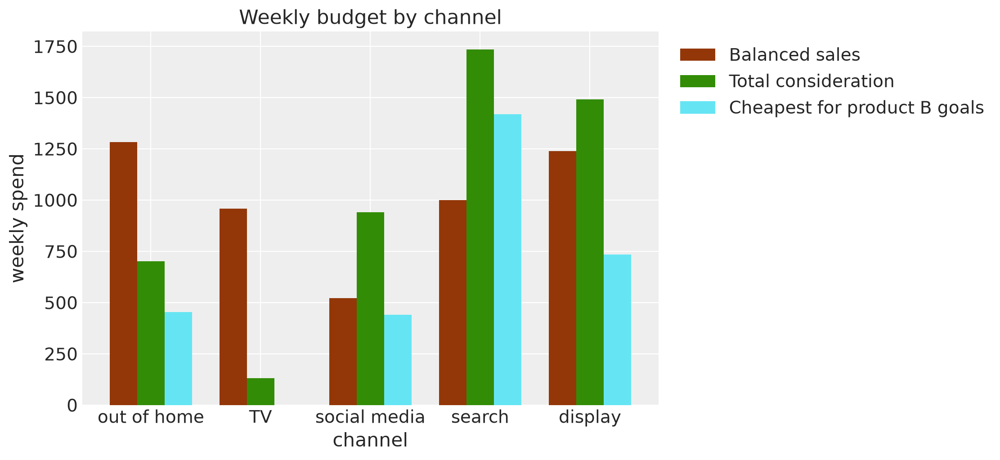

In [58]:
fig, ax = plt.subplots(figsize=(11, 5))
plan_allocations.to_pandas().T.plot.bar(
    ax=ax, rot=0, width=0.75, color=[policy_colors[plan] for plan in plan_names]
)

ax.set(title="Weekly budget by channel", xlabel="channel", ylabel="weekly spend")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0));

The three plans differ most on `TV`, which the cheapest plan skips, on `out of home`, where the cheapest plan spends about a third of the balanced plan's amount, and on `search`, where the total-consideration plan spends about $1{,}750$ against $1{,}000$ for the balanced plan.

Product B's sales under the three plans, with the goal as a dashed line.

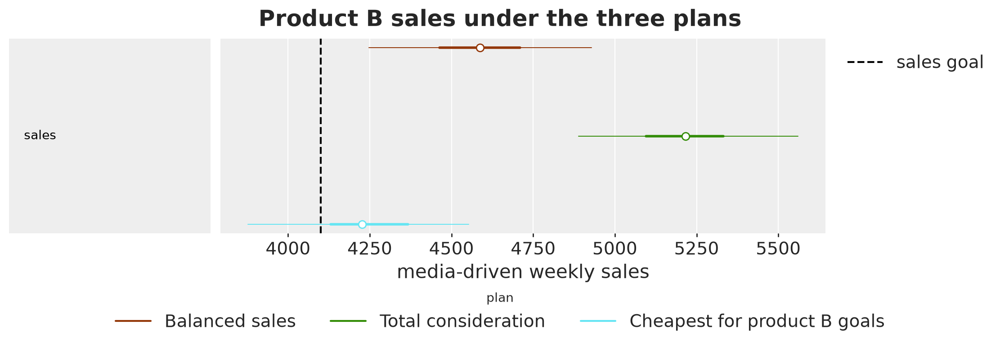

In [59]:
forest_by_group(
    product_b_response.sel(target=["sales"]),
    group_dim="plan",
    row_dim="target",
    title="Product B sales under the three plans",
    xlabel="media-driven weekly sales",
    figsize=(11, 3.8),
    reference=sales_goal,
    reference_label="sales goal",
    colors=policy_colors,
)

The cheapest plan clears the sales goal of $4{,}100$ with about $4{,}230$ on average and a $94\%$ HDI from about $3{,}900$ to $4{,}550$: the sales goal is not what binds. The balanced plan gives product B about $4{,}600$ and the total-consideration plan about $5{,}200$.

And product B's consideration, with its goal.

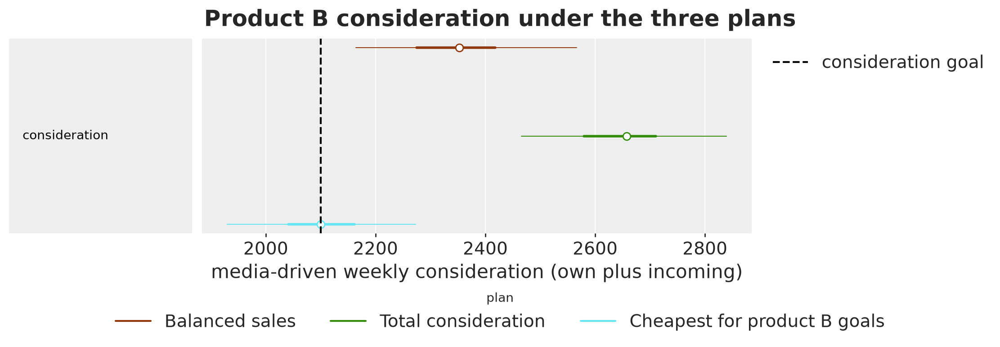

In [60]:
forest_by_group(
    product_b_response.sel(target=["consideration"]),
    group_dim="plan",
    row_dim="target",
    title="Product B consideration under the three plans",
    xlabel="media-driven weekly consideration (own plus incoming)",
    figsize=(11, 3.8),
    reference=consideration_goal,
    reference_label="consideration goal",
    colors=policy_colors,
)

The consideration goal is the binding one: the cheapest plan lands exactly on $2{,}100$, with a $94\%$ HDI from about $1{,}930$ to $2{,}270$. The balanced plan gives about $2{,}350$ and the total-consideration plan about $2{,}660$, because product B's sales channels are also consideration channels.

The same numbers as a table.

In [61]:
product_b_hdi = az.hdi(
    product_b_response.to_dataset(name="value"), prob=HDI_PROB, dim="sample"
)["value"]
product_b_summary = (
    xr.Dataset(
        {
            "posterior mean": product_b_response.mean("sample"),
            "hdi lower": product_b_hdi.sel(ci_bound="lower", drop=True),
            "hdi upper": product_b_hdi.sel(ci_bound="upper", drop=True),
        }
    )
    .drop_vars(["date", "product"])
    .to_dataframe()
)
product_b_summary.round(0)

posterior mean  hdi lower  \
target        plan                                                      
sales         Balanced sales                        4588.0     4248.0   
              Total consideration                   5217.0     4889.0   
              Cheapest for product B goals          4226.0     3878.0   
consideration Balanced sales                        2352.0     2164.0   
              Total consideration                   2657.0     2466.0   
              Cheapest for product B goals          2100.0     1929.0   

                                            hdi upper  
target        plan                                     
sales         Balanced sales                   4929.0  
              Total consideration              5561.0  
              Cheapest for product B goals     4553.0  
consideration Balanced sales                   2566.0  
              Total consideration              2839.0  
              Cheapest for product B goals     2273.0

The cheapest plan sits on the goals *on average*, so a fair share of the posterior draws fall short. The fraction of draws that meet both goals tells how much of a gamble each plan is.

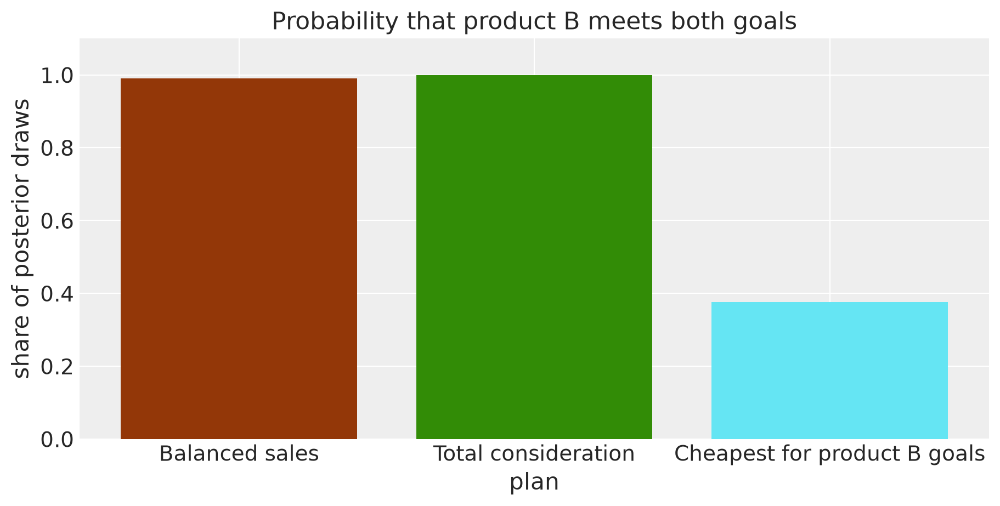

In [62]:
both_goals = (
    (product_b_response.sel(target="sales") >= sales_goal)
    & (product_b_response.sel(target="consideration") >= consideration_goal)
).mean("sample")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(
    plan_names, both_goals.values, color=[policy_colors[plan] for plan in plan_names]
)
ax.set(
    title="Probability that product B meets both goals",
    xlabel="plan",
    ylabel="share of posterior draws",
    ylim=(0, 1.1),
);

The balanced and the total-consideration plans meet both goals in almost every posterior draw. The cheapest plan meets them in fewer than $40\%$ of the draws, which is the price of spending $39\%$ less. If that is not acceptable, the goals should be set on a quantile of the posterior rather than on the mean.

### Plans Against the Truth

We have carried the true parameters through the whole notebook, so we can use them once more. Every plan above was chosen and scored by the fitted model. The generator can tell us what each plan would *really* deliver, and what the best possible plan would have delivered. The steady-state response under the truth is the saturation curve at the weekly budget, plus the spillover routes, which is the `sales` closed form of the frontier section extended to the other two outcomes.

In [63]:
def true_steady_state_response(allocation: xr.DataArray | np.ndarray) -> xr.DataArray:
    """Return the generator's steady-state weekly response to a constant allocation, dims (product, target)."""
    budget = xr.DataArray(
        np.asarray(allocation, dtype=float),
        dims="channel",
        coords={"channel": channels},
    )
    own = true_maximum * budget / (true_half_saturation + budget)
    incoming = (
        true_spill_share * spill_mask * own.rename({"product": "source_product"})
    ).sum(("source_product", "channel"))
    return own.sum("channel") + incoming


def true_total_curves(target: str) -> tuple[np.ndarray, np.ndarray]:
    """Return the saturation curves whose sum is the true total of one outcome, as (maximum, half-saturation) rows.

    The rows are the three products' own curves plus one row per spillover route, whose amplitude is the share
    times the source's amplitude and whose half-saturation is the source's, so that the weighted-sum solver can
    maximize the total.
    """
    own_maximum = true_maximum.sel(target=target).transpose("product", "channel")
    own_half_saturation = true_half_saturation.sel(target=target).transpose(
        "product", "channel"
    )
    routes = spill_mask.sel(target=target)
    source_maximum = own_maximum.rename({"product": "source_product"})
    source_half_saturation = own_half_saturation.rename({"product": "source_product"})
    active_pairs = routes.any("channel").stack(pair=("product", "source_product"))
    route_maximum = (
        (true_spill_share * routes * source_maximum)
        .stack(pair=("product", "source_product"))
        .transpose("pair", "channel")
    )
    route_half_saturation = (
        (source_half_saturation * xr.ones_like(routes, dtype=float))
        .stack(pair=("product", "source_product"))
        .transpose("pair", "channel")
    )
    return (
        np.vstack([own_maximum.values, route_maximum.values[active_pairs.values]]),
        np.vstack(
            [
                own_half_saturation.values,
                route_half_saturation.values[active_pairs.values],
            ]
        ),
    )


def true_best_total(target: str) -> float:
    """Return the largest true total of one outcome at the weekly budget."""
    maximum, half_saturation = true_total_curves(target)
    best_allocation = weighted_product_allocation(
        np.ones(maximum.shape[0]), maximum, half_saturation, weekly_budget
    )
    return float(
        product_response_and_gradient(best_allocation, maximum, half_saturation)[
            0
        ].sum()
    )


true_ideals = xr.DataArray(
    true_ideal_sales, dims="product", coords={"product": products}
)


def truth_row(
    plan_label: str, objective: str, plan: xr.DataArray, model_value: float
) -> dict:
    """Score one plan on one objective: what the model says, what the truth says, and the true optimum."""
    truth = true_steady_state_response(plan)
    if objective == "Product A sales":
        true_value = truth.sel(product="product A", target="sales")
        best = true_ideal_sales[0]
    elif objective == "Product B sales":
        true_value = truth.sel(product="product B", target="sales")
        best = true_ideal_sales[1]
    elif objective == "Total consideration":
        true_value = truth.sel(target="consideration").sum("product")
        best = true_best_total("consideration")
    elif objective == "Total brand":
        true_value = truth.sel(target="brand").sum("product")
        best = true_best_total("brand")
    else:  # Min sales attainment (%), against the true ideals
        true_value = 100 * (truth.sel(target="sales") / true_ideals).min("product")
        best = 100 * true_balance_score
    return {
        "plan": plan_label,
        "objective": objective,
        "model": model_value,
        "truth": float(true_value),
        "true optimum": float(best),
    }


truth_rows = [
    truth_row(
        policy,
        objective,
        priority_allocations.sel(policy=policy),
        policy_scores.loc[policy, objective],
    )
    for policy, objective in [
        ("Product A sales", "Product A sales"),
        ("Product B sales", "Product B sales"),
        ("Total consideration", "Total consideration"),
        ("Total brand", "Total brand"),
        ("Balanced sales", "Min sales attainment (%)"),
    ]
]
# The two total plans scored on each other's objective, and the cheapest plan on its two goals.
truth_rows.append(
    truth_row(
        "Total brand",
        "Total consideration",
        priority_allocations.sel(policy="Total brand"),
        policy_scores.loc["Total brand", "Total consideration"],
    )
)
cheapest_truth = true_steady_state_response(cheapest_allocation).sel(
    product="product B"
)
truth_rows += [
    {
        "plan": "Cheapest for product B goals",
        "objective": "Product B sales",
        "model": float(cheapest_means.sel(target="sales")),
        "truth": float(cheapest_truth.sel(target="sales")),
        "true optimum": np.nan,
        "goal": sales_goal,
    },
    {
        "plan": "Cheapest for product B goals",
        "objective": "Product B consideration",
        "model": float(cheapest_means.sel(target="consideration")),
        "truth": float(cheapest_truth.sel(target="consideration")),
        "true optimum": np.nan,
        "goal": consideration_goal,
    },
]
plans_against_truth = pd.DataFrame(truth_rows).set_index(["plan", "objective"])
plans_against_truth.round(1)

model   truth  \
plan                         objective                                  
Product A sales              Product A sales           5603.8  5484.5   
Product B sales              Product B sales           5545.5  5484.9   
Total consideration          Total consideration       8646.2  8732.7   
Total brand                  Total brand               8162.7  8726.7   
Balanced sales               Min sales attainment (%)    82.7    81.5   
Total brand                  Total consideration       8601.2  8726.7   
Cheapest for product B goals Product B sales           4226.5  4134.7   
                             Product B consideration   2100.0  2155.6   

                                                       true optimum    goal  
plan                         objective                                       
Product A sales              Product A sales                 5486.0     NaN  
Product B sales              Product B sales                 5486.0     NaN  
Total consideration          Total consideration             8759.2     NaN  
Total brand                  Total brand                     8759.2     NaN  
Balanced sales               Min sales attainment (%)          81.5     NaN  
Total brand                  Total consideration             8759.2     NaN  
Cheapest for product B goals Product B sales                    NaN  4100.0  
                             Product B consideration            NaN  2100.0

The plans hold up. On its own objective every fitted plan delivers, under the truth, within $1\%$ of what the true optimum would deliver: the two single-product plans are at the true ideals, the total-consideration plan reaches about $8{,}730$ of a possible $8{,}760$, and the balanced plan gives the worst-off product $81.5\%$ of its true ideal, which is the true max-min score. The model's *estimates* are less exact than its *plans*: it is $1\%$ to $2\%$ optimistic on the single-product sales, about $1\%$ pessimistic on total consideration, and between $6\%$ and $7\%$ pessimistic on total brand, where the data have twice the noise. This is the reason the Key Findings below quote both $81.5\%$ and $83\%$ for the balanced plan: the first is what the plan delivers under the truth, the second is what the fitted model expects.

The brand plan is the instructive row. Twice the noise moved the estimated level down by between $6\%$ and $7\%$ and moved the plan, with more than twice the `TV` spend of the consideration plan, but under the truth it delivers about $8{,}730$ in total consideration, the same as the consideration plan. The objective is flat near its optimum, the same flatness we measured around the max-min plan, so a noisier outcome costs precision in the forecast long before it costs anything in the plan. Finally, the cheapest plan clears both goals under the truth, by small margins: about $4{,}130$ against the sales goal of $4{,}100$, and about $2{,}160$ against the consideration goal of $2{,}100$.

## Conclusion

One shared media budget, three products, and channels that favor different products: there is no single optimal plan, only trade-offs. This notebook showed how to make those trade-offs explicit with a Pareto frontier, how to choose a point on it with a max-min rule, and how to do all of this with the `MMM` class and the budget optimizer on a fitted posterior.

### Key Findings

- **The true sales frontier is strongly curved.** With the true parameters, the max-min plan gives products A and B $81.5\%$ of their best sales and product C about $88\%$, while the corner plans leave the other product with about a tenth of its potential. Moving $5\%$ of the budget away from the max-min plan costs about two points of that score.
- **The `MMM` recovers what the plan needs.** The total media response per product and outcome and the sales channel contributions are inside the $94\%$ bands, with the widest bands where the true effects are close to zero.
- **Shared spend identifies the total, not the split.** Product B's total response to the two route channels has an HDI that covers the truth, while the own and incoming parts stay where the prior put them. The spillover shares have about the same spread after the fit as before it.
- **Every priority has a price.** In the fitted model, the corner plans leave the neglected product at about $10\%$ of its potential, the balanced plan lifts the worst-off product to about $83\%$ ($81.5\%$ under the true parameters, the true optimum) for about $17\%$ of products A's and B's best sales, and the two total policies agree on the totals to within $1\%$ but differ on `TV` and on what they do for product A.
- **Goals can be cheaper than budgets.** The cheapest plan that reaches $90\%$ of the balanced plan's product B outcomes spends about $3{,}050$ per week, $39\%$ less, but meets both goals in fewer than $40\%$ of the posterior draws. Under a cap of $1{,}600$ the consideration goal is out of reach.
- **The plans survive the truth.** Scored with the generator, every fitted plan delivers within $1\%$ of the true optimum on its own objective and the cheapest plan clears both goals. The model is a little optimistic on sales and pessimistic on brand, so the forecasts are less exact than the plans.

### Model Limitations

- **Shared spend hides the split**: the data pin down product B's total response to a channel, not how much of it is its own and how much comes from product A. A real analysis needs product-specific spend or an experiment to say that, see {ref}`mmm_halo`.
- **Means, not guarantees**: the max-min rule protects the worst-off product on average, and the goal-seeking plan meets its goals on average. {ref}`mmm_allocation_assessment` shows how to bring the risk into the objective.
- **Steady state only**: the plans hold a constant weekly budget and ignore the historical carry-over at the start of the horizon, seasonality and trend.

### Recommendations

1. Take the balanced plan as the default and show the frontier to the product owners: every alternative they propose is a point on it with a price for the others.
2. If product B's goals matter more than the shared total, use the cheapest plan as a floor and spend the saving on whichever product the frontier says gains most.
3. Before trusting the spillover share, collect product-specific spend or run a geo test on `out of home`.

## Next Steps

1. **Weights a stakeholder can defend**: replace the max-min rule with explicit priorities and show the resulting point on the frontier.
2. **Goals on a quantile**: set the goals on the $25$th percentile of the posterior instead of the mean and re-solve the minimum-spend problem.
3. **More constraints**: add per-channel caps or minimum spends for committed contracts as further `Constraint` objects.

In [64]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor,nutpie

Last updated: Sat, 10 Oct 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.3.2
nutpie        : 0.16.11

arviz         : 1.2.0
arviz_plots   : 1.2.0
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
plotly        : 6.8.0
pydantic      : 2.13.4
pymc          : 6.3.2
pymc_extras   : 0.15.1
pymc_marketing: 1.1.0
pytensor      : 3.3.2
scipy         : 1.15.3
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

